# Assignment 2: Reproducibility Study -- CellViT (Improved Copy)
## Vision Transformers for Precise Cell Segmentation and Classification

**Course:** Deep Learning | **Department:** AI & Data Science, FAST-NUCES

**Instructors:** Dr. Qurat ul Ain, Dr. Zohair Ahmed, Mr. Ubaid Ur Rehman

---

### Objective
Reproduce the results of **CellViT** (Horst et al., 2024) on the **PanNuke** dataset for nuclei instance segmentation and classification. This improved copy keeps the original Assignment 2 notebook untouched while upgrading the training pipeline into a stronger end-to-end baseline for better hardware.

### Reproduction Tracks
- **Original constrained reproduction:** frozen encoder, short training budget, minimal logging
- **Improved reproduction:** full fine-tuning, class-aware loss weighting, cached preprocessing, stronger validation tracking, and richer result reporting

### Paper Reference
Horst, F., et al. (2024). *CellViT: Vision Transformers for Precise Cell Segmentation and Classification.* Medical Image Analysis. [DOI](https://doi.org/10.1016/j.media.2024.103143)


---
## Table of Contents
1. [Environment Setup & Dependencies](#1-environment-setup)
2. [Dataset Download & Preparation](#2-dataset-preparation)
3. [Data Preprocessing & Augmentation](#3-data-preprocessing)
4. [Model Architecture -- CellViT](#4-model-architecture)
5. [Loss Functions](#5-loss-functions)
6. [Training Pipeline](#6-training-pipeline)
7. [Post-Processing (Watershed)](#7-post-processing)
8. [Evaluation Metrics (PQ, mPQ, F1)](#8-evaluation-metrics)
9. [Run Training & Evaluation](#9-run-training)
10. [Results & Comparison](#10-results)
11. [Reproducibility Discussion](#11-reproducibility-discussion)


---
## 1. Environment Setup & Dependencies <a id='1-environment-setup'></a>

In [57]:
# ============================================================
# 1.1 Install Required Packages
# ============================================================
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
!pip install albumentations scipy scikit-image scikit-learn matplotlib pandas seaborn tqdm opencv-python-headless -q
!pip install timm einops -q

In [58]:
# ============================================================
# 1.2 Import Libraries
# ============================================================
import os
import sys
import math
import json
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional
from tqdm.auto import tqdm

import cv2
from scipy import ndimage
from scipy.ndimage import binary_fill_holes
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from einops import rearrange

warnings.filterwarnings("ignore")

# ============================================================
# 1.3 Reproducibility -- Fix All Seeds
# ============================================================
def set_seed(seed: int = 42):
    '''Set all random seeds for reproducibility.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)
print("Seed fixed at 42 for Python, NumPy, and PyTorch.")


Seed fixed at 42 for Python, NumPy, and PyTorch.


In [59]:
# ============================================================
# 1.4 Configuration
# ============================================================
class Config:
    '''Central configuration for the improved Assignment 2 pipeline.'''

    RUN_NAME = "assignment2_improved"


    # Paths
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

    DATA_DIR = PROJECT_ROOT / "data" / "pannuke"
    OUTPUT_DIR = PROJECT_ROOT / "outputs"
    CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
    LOG_DIR = PROJECT_ROOT / "logs"

    # Dataset
    NUM_CLASSES = 6
    CLASS_NAMES = ["Background", "Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]
    CELL_CLASSES = CLASS_NAMES[1:]
    NUM_CELL_TYPES = 5
    PATCH_SIZE = 256
    NUM_FOLDS = 3
    VAL_RATIO = 0.15

    # Model
    ENCODER_NAME = "vit_base_patch16_224"
    ENCODER_PRETRAINED = True
    EMBED_DIM = 768
    DECODER_CHANNELS = [512, 256, 128, 64]

    # Training
    BATCH_SIZE = 8
    NUM_EPOCHS = 30
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 1e-2
    WARMUP_EPOCHS = 5
    PATIENCE = 8
    NUM_WORKERS = 4
    FREEZE_ENCODER = False
    USE_AMP = True
    CACHE_PREPROCESS = True
    CLASS_WEIGHTED_CE = True
    GRAD_CLIP_NORM = 1.0

    # Loss weights
    LAMBDA_SEG = 1.0
    LAMBDA_HOVER = 1.0
    LAMBDA_CLS = 1.0

    # Reproducibility
    SEED = 42

    # Baseline reproduction for comparison
    BASELINE_RESULTS = {
        "mPQ": 0.0732,
        "F1_detection": 0.2286,
    }

    # Output files
    RESULTS_JSON = OUTPUT_DIR / "assignment2_improved_results.json"
    FOLD_RESULTS_CSV = OUTPUT_DIR / "assignment2_improved_fold_results.csv"
    EXPERIMENT_LOG_JSON = OUTPUT_DIR / "assignment2_improved_experiment_log.json"
    TRAINING_CURVES_PNG = OUTPUT_DIR / "assignment2_improved_training_curves.png"
    CLASSWISE_PQ_PNG = OUTPUT_DIR / "assignment2_improved_class_pq.png"
    SAMPLE_PREDICTIONS_PNG = OUTPUT_DIR / "assignment2_improved_sample_predictions.png"

    @classmethod
    def as_dict(cls):
        return {
            k: getattr(cls, k)
            for k in dir(cls)
            if k.isupper() and not callable(getattr(cls, k))
        }

cfg = Config()

for d in [cfg.OUTPUT_DIR, cfg.CHECKPOINT_DIR, cfg.LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def get_hardware_info():
    info = {
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if torch.cuda.is_available() else 0.0,
        "pytorch_version": torch.__version__,
        "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    }
    return info

hardware_info = get_hardware_info()
print("Improved Assignment 2 configuration loaded.")
print(json.dumps({k: str(v) for k, v in cfg.as_dict().items()}, indent=2))
print(json.dumps(hardware_info, indent=2))


Improved Assignment 2 configuration loaded.
{
  "BASELINE_RESULTS": "{'mPQ': 0.0732, 'F1_detection': 0.2286}",
  "BATCH_SIZE": "8",
  "CACHE_PREPROCESS": "True",
  "CELL_CLASSES": "['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']",
  "CHECKPOINT_DIR": "/home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/checkpoints",
  "CLASSWISE_PQ_PNG": "/home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/outputs/assignment2_improved_class_pq.png",
  "CLASS_NAMES": "['Background', 'Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']",
  "CLASS_WEIGHTED_CE": "True",
  "DATA_DIR": "/home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke",
  "DECODER_CHANNELS": "[512, 256, 128, 64]",
  "EMBED_DIM": "768",
  "ENCODER_NAME": "vit_base_patch16_224",
  "ENCODER_PRETRAINED": "True",
  "EXPERIMENT_LOG_JSON": "/home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/outputs/assignment2_improved_experiment_log.json",
  "F

---
## 2. Dataset Download & Preparation <a id='2-dataset-preparation'></a>

PanNuke is distributed as 3 folds in `.npy` format:
- `images.npy` — shape `(N, 256, 256, 3)` RGB patches
- `masks.npy` — shape `(N, 256, 256, 6)` instance masks per class + background
- `types.npy` — shape `(N,)` tissue type labels (19 types)

Download from: https://warwick.ac.uk/fac/sci/dcs/research/tia/data/pannuke

In [26]:
# ============================================================
# 2.1 Extract Manually Uploaded PanNuke Dataset
# ============================================================
import os
import shutil

cfg.DATA_DIR.mkdir(parents=True, exist_ok=True)

# Extraction with overwrite from local root directory
print("Extracting manually uploaded files...")
try:
    dataset_base = Path("..") / "Dataset"

    for fold_id in [1, 2, 3]:
        zip_path = dataset_base / f"fold_{fold_id}.zip"
        if zip_path.exists():
            target_dir = cfg.DATA_DIR / f"fold{fold_id}"
            target_dir.mkdir(parents=True, exist_ok=True)
            !unzip -o "{zip_path}" -d "{target_dir}"
    
except Exception as e:
    print(f"Extraction error: {e}")

print("\nChecking directory structure...")
for fold_id in range(1, 4):
    fold_dir = cfg.DATA_DIR / f"fold{fold_id}"
    if fold_dir.exists():
        files = list(fold_dir.rglob("*.npy"))
        if len(files) > 0:
            print(f"  Fold {fold_id}: SUCCESS ({len(files)} npy files found)")
            for f in files:
                print(f"    - {f.name}")
        else:
            print(f"  Fold {fold_id}: FAILED (Folder exists but is empty)")
    else:
        print(f"  Fold {fold_id}: NOT FOUND. Please ensure fold_{fold_id}.zip is in /Dataset/")

Extracting manually uploaded files...
Archive:  ../Dataset/fold_1.zip
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/README.md  
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/masks/by-nc-sa.md  
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/masks/README.md  
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/masks/fold1/masks.npy  
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/images/fold1/types.npy  
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold1/Fold 1/images/fold1/images.npy  
Archive:  ../Dataset/fold_2.zip
  inflating: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/data/pannuke/fold2/Fold 2/README.md  
  inflating: /home/apath/W

In [60]:
import numpy as np
from pathlib import Path
import gc

def load_single_fold(fold_id: int):
    '''Load one fold using memory mapping to save RAM.'''
    gc.collect()
    fold_dir =   cfg.DATA_DIR/ f"fold{fold_id}"
    img_files = list(fold_dir.rglob("images.npy"))
    mask_files = list(fold_dir.rglob("masks.npy"))
    type_files = list(fold_dir.rglob("types.npy"))

    if not img_files or not mask_files:
        print(f"Warning: Fold {fold_id} files not found.")
        return None

    try:
        images = np.load(str(img_files[0]), mmap_mode="r")
        masks = np.load(str(mask_files[0]), mmap_mode="r")
        types = np.load(str(type_files[0]), allow_pickle=True) if type_files else None

        print(f"Fold {fold_id} loaded successfully. Images: {images.shape}, Masks: {masks.shape}")
        return images, masks, types
    except Exception as e:
        print(f"Error loading fold {fold_id}: {e}")
        return None

current_fold_data = None

def activate_fold(fold_id: int):
    global current_fold_data
    current_fold_data = None
    gc.collect()
    current_fold_data = load_single_fold(fold_id)

activate_fold(1)

fold_data = {}
fold_summaries = []

print("Mapping memory-mapped folds for cross-validation...")
for f_id in range(1, cfg.NUM_FOLDS + 1):
    data = load_single_fold(f_id)
    if data:
        fold_data[f_id] = {
            "images": data[0],
            "masks": data[1],
            "types": data[2],
        }
        fold_summaries.append(
            {
                "fold": f_id,
                "num_images": len(data[0]),
                "image_shape": tuple(data[0].shape[1:]),
                "mask_shape": tuple(data[1].shape[1:]),
            }
        )

fold_summary_df = pd.DataFrame(fold_summaries)
print(f"Successfully mapped {len(fold_data)} folds into 'fold_data'.")
if not fold_summary_df.empty:
    print("Dataset fold summary:")
    display(fold_summary_df)


Fold 1 loaded successfully. Images: (2656, 256, 256, 3), Masks: (2656, 256, 256, 6)
Mapping memory-mapped folds for cross-validation...
Fold 1 loaded successfully. Images: (2656, 256, 256, 3), Masks: (2656, 256, 256, 6)
Fold 2 loaded successfully. Images: (2523, 256, 256, 3), Masks: (2523, 256, 256, 6)
Fold 3 loaded successfully. Images: (2656, 256, 256, 3), Masks: (2656, 256, 256, 6)
Successfully mapped 3 folds into 'fold_data'.
Dataset fold summary:


,fold,num_images,image_shape,mask_shape
0,1,2656,"(256, 256, 3)","(256, 256, 6)"
1,2,2523,"(256, 256, 3)","(256, 256, 6)"
2,3,2656,"(256, 256, 3)","(256, 256, 6)"


In [61]:
# ============================================================
# 2.2 Prepare fold_data dictionary for Training
# ============================================================
fold_data = {}

print("Mapping memory-mapped folds for cross-validation...")
for f_id in range(1, 4):
    data = load_single_fold(f_id)
    if data:
        fold_data[f_id] = {
            'images': data[0],
            'masks': data[1],
            'types': data[2]
        }

print(f"Successfully mapped {len(fold_data)} folds into 'fold_data'.")

Mapping memory-mapped folds for cross-validation...
Fold 1 loaded successfully. Images: (2656, 256, 256, 3), Masks: (2656, 256, 256, 6)
Fold 2 loaded successfully. Images: (2523, 256, 256, 3), Masks: (2523, 256, 256, 6)
Fold 3 loaded successfully. Images: (2656, 256, 256, 3), Masks: (2656, 256, 256, 6)
Successfully mapped 3 folds into 'fold_data'.


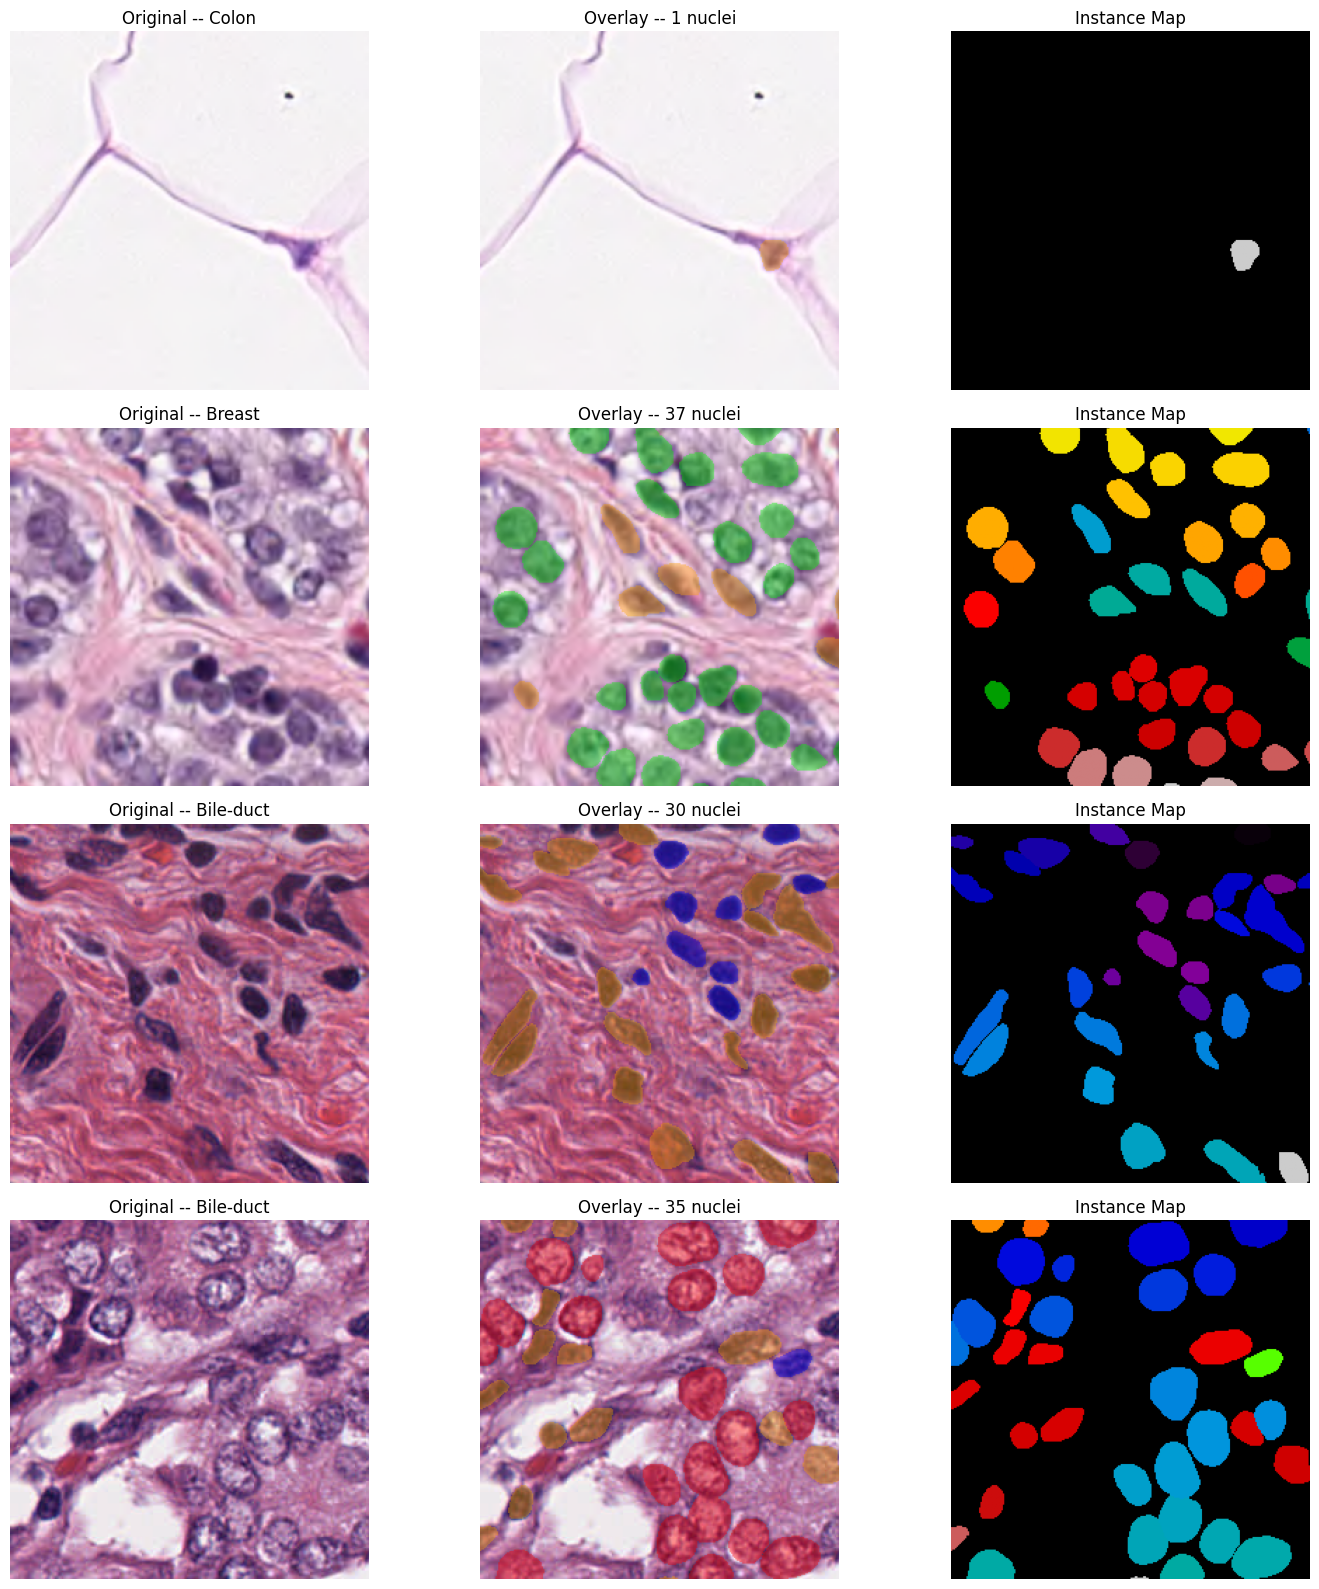

In [62]:
import matplotlib.pyplot as plt

# ============================================================
# 2.3 Visualize Sample Data
# ============================================================
def visualize_pannuke_samples(images, masks, types, n_samples=4):
    '''Visualize sample images with their mask overlays.'''
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4 * n_samples))
    colors = {
        0: [255, 0, 0],
        1: [0, 0, 255],
        2: [255, 165, 0],
        3: [128, 128, 128],
        4: [0, 255, 0],
    }

    indices = np.random.choice(len(images), n_samples, replace=False)
    for row, idx in enumerate(indices):
        img = images[idx].astype(np.uint8)
        mask = masks[idx]
        tissue = types[idx] if types is not None else "unknown"

        overlay = img.copy().astype(np.float32)
        for cls_id in range(5):
            binary = (mask[:, :, cls_id] > 0).astype(np.float32)
            for c in range(3):
                overlay[:, :, c] = overlay[:, :, c] * (1 - 0.4 * binary) + colors[cls_id][c] * 0.4 * binary
        overlay = np.clip(overlay, 0, 255).astype(np.uint8)

        total_nuclei = 0
        for cls_id in range(5):
            unique_ids = np.unique(mask[:, :, cls_id])
            total_nuclei += len(unique_ids[unique_ids > 0])

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(f"Original -- {tissue}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title(f"Overlay -- {total_nuclei} nuclei")
        axes[row, 1].axis("off")

        combined = np.zeros((256, 256), dtype=np.int32)
        offset = 0
        for cls_id in range(5):
            ch = mask[:, :, cls_id]
            unique_ids = np.unique(ch)
            for uid in unique_ids:
                if uid > 0:
                    combined[ch == uid] = offset + uid
            if len(unique_ids) > 0:
                offset += int(unique_ids.max()) + 1

        axes[row, 2].imshow(combined, cmap="nipy_spectral")
        axes[row, 2].set_title("Instance Map")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / "assignment2_improved_sample_data.png", dpi=150, bbox_inches="tight")
    plt.show()

if current_fold_data:
    visualize_pannuke_samples(current_fold_data[0], current_fold_data[1], current_fold_data[2])


---
## 3. Data Preprocessing & Augmentation <a id='3-data-preprocessing'></a>

Following CellViT, this improved reproduction:
1. Applies **Macenko stain normalization** to reduce inter-lab staining variability
2. Generates **HoVer maps** (horizontal/vertical distance maps) for instance separation
3. Uses **cached preprocessing** so expensive targets are computed once per sample
4. Applies controlled histology-safe augmentation (flips, rotate 90, slight color jitter, blur)


In [63]:
# ============================================================
# 3.1 Macenko Stain Normalization
# ============================================================
class MacenkoNormalizer:
    """
    Macenko stain normalization for H&E images.
    Decomposes the image into H and E stain channels using SVD,
    then normalizes to a reference image's stain vectors.
    """
    def __init__(self):
        # Default reference stain vectors (from CellViT / common H&E reference)
        self.HERef = np.array([[0.5626, 0.2159],
                               [0.7201, 0.8012],
                               [0.4062, 0.5581]])
        self.maxCRef = np.array([1.9705, 1.0308])
        self.Io = 240  # Transmitted light intensity
        self.alpha = 1  # Percentile for robust min/max
        self.beta = 0.15  # OD threshold

    def fit(self, target_image: np.ndarray):
        """Fit normalizer to a reference/target image."""
        self.HERef, self.maxCRef = self._get_stain_vectors(target_image)
        return self

    def transform(self, image: np.ndarray) -> np.ndarray:
        """Normalize an image to match the reference stain."""
        try:
            h, w, c = image.shape
            img = image.reshape(-1, 3).astype(np.float64)

            # Convert to Optical Density
            img = np.maximum(img, 1)
            OD = -np.log(img / self.Io)

            # Remove pixels with low OD
            ODhat = OD[~np.any(OD < self.beta, axis=1)]

            if ODhat.shape[0] < 10:
                return image  # Not enough tissue pixels

            # SVD on thresholded OD values
            _, V = np.linalg.eigh(np.cov(ODhat.T))
            V = V[:, [2, 1]]  # Top 2 eigenvectors

            # Project and find angle extremes
            That = ODhat @ V
            phi = np.arctan2(That[:, 1], That[:, 0])
            minPhi = np.percentile(phi, self.alpha)
            maxPhi = np.percentile(phi, 100 - self.alpha)

            vMin = V @ np.array([np.cos(minPhi), np.sin(minPhi)])
            vMax = V @ np.array([np.cos(maxPhi), np.sin(maxPhi)])

            # Ensure H stain is first
            HE = np.array([vMin, vMax]).T
            if HE[0, 0] < HE[0, 1]:
                HE = HE[:, [1, 0]]

            HE = HE / np.linalg.norm(HE, axis=0)

            # Compute concentrations
            Y = OD.reshape(-1, 3)
            C = np.linalg.lstsq(HE, Y.T, rcond=None)[0]

            maxC = np.array([np.percentile(C[0, :], 99), np.percentile(C[1, :], 99)])

            # Normalize
            C = C * (self.maxCRef / maxC)[:, None]

            # Reconstruct
            Inorm = self.Io * np.exp(-self.HERef @ C)
            Inorm = np.clip(Inorm, 0, 255).T.reshape(h, w, 3).astype(np.uint8)

            return Inorm
        except Exception:
            return image  # Return original on failure

    def _get_stain_vectors(self, image):
        """Extract stain vectors from an image."""
        h, w, c = image.shape
        img = image.reshape(-1, 3).astype(np.float64)
        img = np.maximum(img, 1)
        OD = -np.log(img / self.Io)
        ODhat = OD[~np.any(OD < self.beta, axis=1)]

        _, V = np.linalg.eigh(np.cov(ODhat.T))
        V = V[:, [2, 1]]

        That = ODhat @ V
        phi = np.arctan2(That[:, 1], That[:, 0])
        minPhi = np.percentile(phi, self.alpha)
        maxPhi = np.percentile(phi, 100 - self.alpha)

        vMin = V @ np.array([np.cos(minPhi), np.sin(minPhi)])
        vMax = V @ np.array([np.cos(maxPhi), np.sin(maxPhi)])

        HE = np.array([vMin, vMax]).T
        if HE[0, 0] < HE[0, 1]:
            HE = HE[:, [1, 0]]
        HE = HE / np.linalg.norm(HE, axis=0)

        Y = OD.reshape(-1, 3)
        C = np.linalg.lstsq(HE, Y.T, rcond=None)[0]
        maxC = np.array([np.percentile(C[0, :], 99), np.percentile(C[1, :], 99)])

        return HE, maxC

stain_normalizer = MacenkoNormalizer()
print("Macenko stain normalizer initialized.")

Macenko stain normalizer initialized.


In [65]:
# ============================================================
# 3.2 HoVer Map Generation
# ============================================================
def generate_hover_maps(instance_mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate Horizontal and Vertical distance maps from an instance mask.

    For each pixel inside a nucleus, compute its normalized distance
    to the nucleus centroid along H and V axes. Values range [-1, 1].

    Args:
        instance_mask: (H, W) with unique integer IDs per nucleus instance
    Returns:
        h_map: (H, W) horizontal distance map
        v_map: (H, W) vertical distance map
    """
    h, w = instance_mask.shape
    h_map = np.zeros((h, w), dtype=np.float32)
    v_map = np.zeros((h, w), dtype=np.float32)

    instance_ids = np.unique(instance_mask)
    instance_ids = instance_ids[instance_ids > 0]  # Remove background

    for inst_id in instance_ids:
        inst_pixels = (instance_mask == inst_id)
        ys, xs = np.where(inst_pixels)

        if len(ys) == 0:
            continue

        # Centroid
        cy, cx = ys.mean(), xs.mean()

        # Bounding box extents for normalization
        y_min, y_max = ys.min(), ys.max()
        x_min, x_max = xs.min(), xs.max()

        y_range = max(y_max - y_min, 1)
        x_range = max(x_max - x_min, 1)

        # Normalized distances to centroid [-1, 1]
        h_map[ys, xs] = (xs - cx) / (x_range / 2 + 1e-6)
        v_map[ys, xs] = (ys - cy) / (y_range / 2 + 1e-6)

    # Clip to [-1, 1]
    h_map = np.clip(h_map, -1, 1)
    v_map = np.clip(v_map, -1, 1)

    return h_map, v_map


def pannuke_masks_to_targets(mask_6ch: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Convert PanNuke 6-channel mask into training targets.

    Args:
        mask_6ch: (H, W, 6) — channels [Neoplastic, Inflammatory, Connective, Dead, Epithelial, BG]
    Returns:
        dict with keys:
            'binary_mask': (H, W) — 0/1 nuclei vs background
            'hover_h': (H, W) — horizontal distance map
            'hover_v': (H, W) — vertical distance map
            'class_map': (H, W) — per-pixel class labels (0=BG, 1-5=cell types)
            'instance_map': (H, W) — combined instance IDs
    """
    h, w = mask_6ch.shape[:2]

    # Build combined instance map and class map
    instance_map = np.zeros((h, w), dtype=np.int32)
    class_map = np.zeros((h, w), dtype=np.int64)

    offset = 0
    for cls_id in range(5):  # 5 cell type channels
        ch = mask_6ch[:, :, cls_id].astype(np.int32)
        unique_ids = np.unique(ch)
        unique_ids = unique_ids[unique_ids > 0]

        for uid in unique_ids:
            pixel_mask = (ch == uid)
            instance_map[pixel_mask] = offset + uid
            class_map[pixel_mask] = cls_id + 1  # 1-indexed class

        if len(unique_ids) > 0:
            offset += int(unique_ids.max()) + 1

    # Binary mask
    binary_mask = (instance_map > 0).astype(np.float32)

    # HoVer maps
    hover_h, hover_v = generate_hover_maps(instance_map)

    return {
        'binary_mask': binary_mask,
        'hover_h': hover_h,
        'hover_v': hover_v,
        'class_map': class_map,
        'instance_map': instance_map
    }

print("Target generation functions ready.")

Target generation functions ready.


In [66]:
import numpy as np
from pathlib import Path
import gc

PREPROCESS_CACHE = {}

def build_cache_key(sample_key):
    return tuple(sample_key)

class PanNukeDataset(Dataset):
    '''
    PyTorch Dataset for PanNuke with optional preprocessing cache.
    '''
    def __init__(self, fold_data, sample_keys, transform=None, stain_norm=True, img_size=256,
                 cache=None, use_cache=True):
        self.fold_data = fold_data
        self.sample_keys = list(sample_keys)
        self.transform = transform
        self.stain_norm = stain_norm
        self.normalizer = MacenkoNormalizer()
        self.img_size = img_size
        self.cache = cache if cache is not None else {}
        self.use_cache = use_cache

    def __len__(self):
        return len(self.sample_keys)

    def _load_raw(self, sample_key):
        fold_id, local_idx = sample_key
        image = np.array(self.fold_data[fold_id]["images"][local_idx], dtype=np.uint8)
        mask = np.array(self.fold_data[fold_id]["masks"][local_idx])

        if image.shape[0] != self.img_size or image.shape[1] != self.img_size:
            image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            resized_mask = np.zeros((self.img_size, self.img_size, mask.shape[2]), dtype=mask.dtype)
            for c in range(mask.shape[2]):
                resized_mask[:, :, c] = cv2.resize(
                    mask[:, :, c].astype(np.float32),
                    (self.img_size, self.img_size),
                    interpolation=cv2.INTER_NEAREST,
                ).astype(mask.dtype)
            mask = resized_mask

        if self.stain_norm:
            image = self.normalizer.transform(image)

        targets = pannuke_masks_to_targets(mask)
        return {
            "image": image,
            "binary_mask": targets["binary_mask"],
            "hover_h": targets["hover_h"],
            "hover_v": targets["hover_v"],
            "class_map": targets["class_map"],
        }

    def __getitem__(self, idx):
        sample_key = self.sample_keys[idx]
        cache_key = build_cache_key(sample_key)

        if self.use_cache and cache_key in self.cache:
            item = self.cache[cache_key]
        else:
            item = self._load_raw(sample_key)
            if self.use_cache:
                self.cache[cache_key] = {
                    "image": item["image"].copy(),
                    "binary_mask": item["binary_mask"].copy(),
                    "hover_h": item["hover_h"].copy(),
                    "hover_v": item["hover_v"].copy(),
                    "class_map": item["class_map"].copy(),
                }

        image = item["image"].copy()
        binary_mask = item["binary_mask"].copy()
        hover_h = item["hover_h"].copy()
        hover_v = item["hover_v"].copy()
        class_map = item["class_map"].copy()

        if self.transform is not None:
            stacked_masks = np.stack(
                [binary_mask, hover_h, hover_v, class_map.astype(np.float32)],
                axis=-1,
            )
            augmented = self.transform(image=image, mask=stacked_masks)
            image = augmented["image"]
            aug_masks = augmented["mask"]
            if isinstance(aug_masks, torch.Tensor):
                binary_mask = aug_masks[:, :, 0].float()
                hover_h = aug_masks[:, :, 1].float()
                hover_v = aug_masks[:, :, 2].float()
                class_map = aug_masks[:, :, 3].long()
            else:
                binary_mask = torch.tensor(aug_masks[:, :, 0], dtype=torch.float32)
                hover_h = torch.tensor(aug_masks[:, :, 1], dtype=torch.float32)
                hover_v = torch.tensor(aug_masks[:, :, 2], dtype=torch.float32)
                class_map = torch.tensor(aug_masks[:, :, 3], dtype=torch.long)
        else:
            image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32) / 255.0
            binary_mask = torch.tensor(binary_mask, dtype=torch.float32)
            hover_h = torch.tensor(hover_h, dtype=torch.float32)
            hover_v = torch.tensor(hover_v, dtype=torch.float32)
            class_map = torch.tensor(class_map, dtype=torch.long)

        return {
            "image": image,
            "binary_mask": binary_mask,
            "hover_h": hover_h,
            "hover_v": hover_v,
            "class_map": class_map,
            "sample_key": sample_key,
        }


def get_train_transforms():
    '''Training augmentation pipeline with controlled histology-safe transforms.'''
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.05, p=0.4),
        A.GaussianBlur(blur_limit=(3, 5), p=0.15),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])


def get_val_transforms():
    '''Validation/test transforms -- normalization only.'''
    return A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

print("Dataset class, preprocessing cache, and augmentation pipelines ready.")


Dataset class, preprocessing cache, and augmentation pipelines ready.


In [67]:
# ============================================================
# 3.5 Create Genuine Fold-Aware Dataloaders
# ============================================================
def build_sample_keys(fold_ids):
    sample_keys = []
    for fold_id in fold_ids:
        for local_idx in range(len(fold_data[fold_id]["images"])):
            sample_keys.append((fold_id, local_idx))
    return sample_keys


def split_train_val_keys(train_keys, val_ratio=0.15, seed=42):
    rng = random.Random(seed)
    shuffled = train_keys.copy()
    rng.shuffle(shuffled)
    val_count = max(1, int(len(shuffled) * val_ratio))
    val_keys = shuffled[:val_count]
    train_only_keys = shuffled[val_count:]
    return train_only_keys, val_keys


def compute_class_weights(fold_data, sample_keys, num_classes=6):
    counts = np.ones(num_classes, dtype=np.float64)
    for fold_id, local_idx in tqdm(sample_keys, desc="Computing class weights", leave=False):
        mask_6ch = np.array(fold_data[fold_id]["masks"][local_idx])
        class_map = pannuke_masks_to_targets(mask_6ch)["class_map"]
        counts += np.bincount(class_map.reshape(-1), minlength=num_classes)

    freqs = counts / counts.sum()
    weights = 1.0 / np.sqrt(freqs)
    weights[0] *= 0.5
    weights = weights * (num_classes / weights.sum())
    return torch.tensor(weights, dtype=torch.float32)


def describe_fold_split(train_keys, val_keys, test_keys):
    return pd.DataFrame(
        [
            {"split": "train", "samples": len(train_keys)},
            {"split": "val", "samples": len(val_keys)},
            {"split": "test", "samples": len(test_keys)},
        ]
    )


def create_fold_dataloaders(fold_data: dict, test_fold: int, batch_size: int = 2, num_workers: int = 0):
    '''
    Genuine 3-fold CV:
    - test set: held-out fold only
    - train pool: remaining folds
    - validation: seeded split from training pool only
    '''
    train_folds = [fold_id for fold_id in sorted(fold_data.keys()) if fold_id != test_fold]
    test_folds = [test_fold]

    train_pool_keys = build_sample_keys(train_folds)
    test_keys = build_sample_keys(test_folds)
    train_keys, val_keys = split_train_val_keys(train_pool_keys, val_ratio=cfg.VAL_RATIO, seed=cfg.SEED + test_fold)

    split_df = describe_fold_split(train_keys, val_keys, test_keys)
    print(f"Fold split summary for held-out fold {test_fold}:")
    display(split_df)

    train_dataset = PanNukeDataset(
        fold_data,
        train_keys,
        transform=get_train_transforms(),
        stain_norm=True,
        img_size=cfg.PATCH_SIZE,
        cache=PREPROCESS_CACHE,
        use_cache=cfg.CACHE_PREPROCESS,
    )
    val_dataset = PanNukeDataset(
        fold_data,
        val_keys,
        transform=get_val_transforms(),
        stain_norm=True,
        img_size=cfg.PATCH_SIZE,
        cache=PREPROCESS_CACHE,
        use_cache=cfg.CACHE_PREPROCESS,
    )
    test_dataset = PanNukeDataset(
        fold_data,
        test_keys,
        transform=get_val_transforms(),
        stain_norm=True,
        img_size=cfg.PATCH_SIZE,
        cache=PREPROCESS_CACHE,
        use_cache=cfg.CACHE_PREPROCESS,
    )

    pin_memory = torch.cuda.is_available()
    loader_kwargs = {
        "num_workers": num_workers,
        "pin_memory": pin_memory,
    }

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False, **loader_kwargs)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False, **loader_kwargs)

    class_weights = compute_class_weights(fold_data, train_keys, num_classes=cfg.NUM_CLASSES) if cfg.CLASS_WEIGHTED_CE else None
    return train_loader, val_loader, test_loader, class_weights, split_df

print("Fold-aware DataLoader factory with validation split and class weighting is ready.")


Fold-aware DataLoader factory with validation split and class weighting is ready.


In [68]:
# ============================================================
# 4.1 ViT Encoder with Feature Extraction (Fixed)
# ============================================================
class ViTEncoder(nn.Module):
    def __init__(self, model_name: str = "vit_large_patch16_224",
                 pretrained: bool = True, img_size: int = 256):
        super().__init__()
        # Create the model using timm
        self.vit = timm.create_model(
            model_name,
            pretrained=pretrained,
            img_size=img_size,
            num_classes=0,
            global_pool='',
            dynamic_img_size=True
        )
        self.embed_dim = self.vit.embed_dim
        self.num_blocks = len(self.vit.blocks)

        # Extract features at 4 intervals for the decoder
        self.extraction_layers = [
            self.num_blocks // 4 - 1,
            self.num_blocks // 2 - 1,
            3 * self.num_blocks // 4 - 1,
            self.num_blocks - 1
        ]

    def forward(self, x: torch.Tensor) -> List[torch.Tensor]:
        B, C, H, W = x.shape

        # Use timm's internal methods to handle patch embedding and pos_embed correctly
        x = self.vit.patch_embed(x)
        x = self.vit._pos_embed(x)
        x = self.vit.patch_drop(x)
        x = self.vit.norm_pre(x)

        features = []
        for i, block in enumerate(self.vit.blocks):
            x = block(x)
            if i in self.extraction_layers:
                # x shape: [B, N+1, C] where N is number of patches
                # Remove class token and reshape to spatial
                feat = x[:, 1:, :]
                num_patches = feat.shape[1]
                grid_size = int(math.sqrt(num_patches))

                # Reshape to (B, C, H, W)
                feat = feat.transpose(1, 2).reshape(B, self.embed_dim, grid_size, grid_size)
                features.append(feat)

        return features

In [69]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int = 3, padding: int = 1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, padding=padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch, kernel_size=2, stride=2)
        # After concatenation, in_channels = in_ch + skip_ch
        self.conv1 = ConvBnRelu(in_ch + skip_ch, out_ch)
        self.conv2 = ConvBnRelu(out_ch, out_ch)
    def forward(self, x, skip=None):
        x = self.upsample(x)
        if skip is not None:
            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.conv2(self.conv1(x))

class TaskDecoder(nn.Module):
    def __init__(self, encoder_channels: List[int], decoder_channels: List[int], out_channels: int, img_size: int = 256):
        super().__init__()
        self.img_size = img_size

        # Reverse encoder channels to match decoder flow (bottom-up)
        enc_chs = encoder_channels[::-1]

        self.bottleneck = ConvBnRelu(enc_chs[0], decoder_channels[0])

        self.blocks = nn.ModuleList()
        curr_ch = decoder_channels[0]

        for i in range(len(decoder_channels) - 1):
            skip_ch = enc_chs[i+1] if (i+1) < len(enc_chs) else 0
            next_ch = decoder_channels[i+1]
            self.blocks.append(DecoderBlock(curr_ch, skip_ch, next_ch))
            curr_ch = next_ch

        self.output_head = nn.Sequential(
            nn.Conv2d(curr_ch, curr_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(curr_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(curr_ch, out_channels, 1)
        )

    def forward(self, encoder_features):
        # Features from encoder: [feat1, feat2, feat3, feat4] (lowest to highest resolution)
        feats = encoder_features[::-1]
        x = self.bottleneck(feats[0])

        for i, block in enumerate(self.blocks):
            skip = feats[i+1] if (i+1) < len(feats) else None
            x = block(x, skip)

        x = F.interpolate(x, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
        return self.output_head(x)

In [70]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CellViT(nn.Module):
    def __init__(self, encoder_name: str = "vit_large_patch16_224", pretrained: bool = True,
                 num_classes: int = 6, decoder_channels: List[int] = [512, 256, 128, 64], img_size: int = 256):
        super().__init__()
        self.encoder = ViTEncoder(encoder_name, pretrained, img_size)

        self.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            feats = self.encoder(dummy)
            encoder_channels = [f.shape[1] for f in feats]
        self.train()

        print(f"Detected encoder channels: {encoder_channels}")

        self.seg_decoder = TaskDecoder(encoder_channels, decoder_channels, 2, img_size)
        self.hover_decoder = TaskDecoder(encoder_channels, decoder_channels, 2, img_size)
        self.cls_decoder = TaskDecoder(encoder_channels, decoder_channels, num_classes, img_size)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        encoder_features = self.encoder(x)
        return {
            "seg": self.seg_decoder(encoder_features),
            "hover": self.hover_decoder(encoder_features),
            "cls": self.cls_decoder(encoder_features),
        }

model = CellViT(
    encoder_name=cfg.ENCODER_NAME,
    pretrained=cfg.ENCODER_PRETRAINED,
    num_classes=cfg.NUM_CLASSES,
    decoder_channels=cfg.DECODER_CHANNELS,
    img_size=cfg.PATCH_SIZE,
).to(device)

if getattr(cfg, "FREEZE_ENCODER", False):
    for param in model.encoder.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)")

dummy_input = torch.randn(1, 3, 256, 256).to(device)
model.eval()
with torch.no_grad():
    outputs = model(dummy_input)

print("\nOutput shapes:")
for key, val in outputs.items():
    print(f"  {key}: {tuple(val.shape)}")


Detected encoder channels: [768, 768, 768, 768]
Device: cuda
Trainable params: 116,970,122 / 116,970,122 (100.0%)

Output shapes:
  seg: (1, 2, 256, 256)
  hover: (1, 2, 256, 256)
  cls: (1, 6, 256, 256)


---
## 5. Loss Functions <a id='5-loss-functions'></a>

CellViT uses a weighted multi-task loss:

$$\mathcal{L}_{\text{total}} = \lambda_{\text{seg}} \cdot (\mathcal{L}_{\text{BCE}} + \mathcal{L}_{\text{Dice}}) + \lambda_{\text{hover}} \cdot \mathcal{L}_{\text{MSE}} + \lambda_{\text{cls}} \cdot \mathcal{L}_{\text{CE}}$$

In this improved run, the classification branch uses **class-weighted cross-entropy** to handle rare classes more explicitly.


In [71]:
# ============================================================
# 5.1 Dice Loss
# ============================================================
class DiceLoss(nn.Module):
    '''Dice loss for binary segmentation.'''
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred_soft = F.softmax(pred, dim=1)[:, 1]
        intersection = (pred_soft * target).sum(dim=(1, 2))
        union = pred_soft.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()


class HoVerLoss(nn.Module):
    '''MSE loss for HoVer maps, computed only on nuclei pixels.'''
    def __init__(self):
        super().__init__()

    def forward(self, pred: torch.Tensor, target_h: torch.Tensor, target_v: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        pred_h = pred[:, 0]
        pred_v = pred[:, 1]
        n_pixels = mask.sum() + 1e-6
        loss_h = ((pred_h - target_h) ** 2 * mask).sum() / n_pixels
        loss_v = ((pred_v - target_v) ** 2 * mask).sum() / n_pixels
        return loss_h + loss_v


class CellViTLoss(nn.Module):
    '''
    Combined multi-task loss for CellViT.
    '''
    def __init__(self, lambda_seg=1.0, lambda_hover=1.0, lambda_cls=1.0, class_weights=None):
        super().__init__()
        self.lambda_seg = lambda_seg
        self.lambda_hover = lambda_hover
        self.lambda_cls = lambda_cls
        self.bce_loss = nn.CrossEntropyLoss()
        self.dice_loss = DiceLoss()
        self.hover_loss = HoVerLoss()
        self.cls_loss = nn.CrossEntropyLoss(weight=class_weights)

    def forward(self, outputs: Dict[str, torch.Tensor], targets: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        binary_mask = targets["binary_mask"]
        hover_h = targets["hover_h"]
        hover_v = targets["hover_v"]
        class_map = targets["class_map"]

        seg_target = binary_mask.long()
        loss_bce = self.bce_loss(outputs["seg"], seg_target)
        loss_dice = self.dice_loss(outputs["seg"], binary_mask)
        loss_seg = loss_bce + loss_dice

        loss_hover = self.hover_loss(outputs["hover"], hover_h, hover_v, binary_mask)
        loss_cls = self.cls_loss(outputs["cls"], class_map)

        loss_total = (
            self.lambda_seg * loss_seg
            + self.lambda_hover * loss_hover
            + self.lambda_cls * loss_cls
        )

        return {
            "total": loss_total,
            "seg": loss_seg.detach(),
            "hover": loss_hover.detach(),
            "cls": loss_cls.detach(),
        }


criterion = CellViTLoss(
    lambda_seg=cfg.LAMBDA_SEG,
    lambda_hover=cfg.LAMBDA_HOVER,
    lambda_cls=cfg.LAMBDA_CLS,
    class_weights=None,
)
print("Loss functions defined.")
print(f"  Weights: seg={cfg.LAMBDA_SEG}, hover={cfg.LAMBDA_HOVER}, cls={cfg.LAMBDA_CLS}")


Loss functions defined.
  Weights: seg=1.0, hover=1.0, cls=1.0


---
## 6. Training Pipeline <a id='6-training-pipeline'></a>

Improvements in this copied notebook:
- end-to-end fine-tuning from epoch 0
- mixed precision training and evaluation
- per-epoch validation loss, mPQ, and F1 tracking
- best-checkpoint selection
- structured fold histories for downstream comparison


In [72]:
# ============================================================
# 6.1 Learning Rate Scheduler (Warm-up + Cosine Decay)
# UPDATED WITH CHECKPOINT SUPPORT
# ============================================================
import math


class WarmupCosineScheduler:
    """
    Linear warmup followed by cosine decay LR schedule.

    Supports:
    state_dict()
    load_state_dict()
    exact resume after crash
    """

    def __init__(
        self,
        optimizer,
        warmup_epochs: int,
        total_epochs: int,
        min_lr: float = 1e-7
    ):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr

        self.base_lrs = [pg["lr"] for pg in optimizer.param_groups]
        self.current_epoch = 0

    def step(self):
        self.current_epoch += 1
        self._apply_lr()

    def _apply_lr(self):

        if self.current_epoch <= self.warmup_epochs:
            scale = self.current_epoch / max(self.warmup_epochs, 1)

        else:
            progress = (
                (self.current_epoch - self.warmup_epochs)
                / max(self.total_epochs - self.warmup_epochs, 1)
            )

            scale = 0.5 * (1 + math.cos(math.pi * progress))

        for pg, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            pg["lr"] = max(base_lr * scale, self.min_lr)

    def get_lr(self):
        return [pg["lr"] for pg in self.optimizer.param_groups]

    # ========================================================
    # CHECKPOINT SAVE SUPPORT
    # ========================================================
    def state_dict(self):
        return {
            "current_epoch": self.current_epoch,
            "base_lrs": self.base_lrs,
            "warmup_epochs": self.warmup_epochs,
            "total_epochs": self.total_epochs,
            "min_lr": self.min_lr,
        }

    # ========================================================
    # CHECKPOINT LOAD SUPPORT
    # ========================================================
    def load_state_dict(self, state_dict):

        self.current_epoch = state_dict["current_epoch"]
        self.base_lrs = state_dict["base_lrs"]
        self.warmup_epochs = state_dict["warmup_epochs"]
        self.total_epochs = state_dict["total_epochs"]
        self.min_lr = state_dict["min_lr"]

        # restore optimizer lr immediately
        self._apply_lr()


# ============================================================
# EARLY STOPPING
# ============================================================
class EarlyStopping:
    """Early stopping to halt training when validation loss stops improving."""

    def __init__(
        self,
        patience: int = 10,
        min_delta: float = 1e-4,
        mode: str = "min"
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode

        self.counter = 0
        self.best_value = None
        self.should_stop = False

    def __call__(self, value: float) -> bool:

        if self.best_value is None:
            self.best_value = value
            return False

        if self.mode == "min":
            improved = value < (self.best_value - self.min_delta)
        else:
            improved = value > (self.best_value + self.min_delta)

        if improved:
            self.best_value = value
            self.counter = 0
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

        return self.should_stop


print("Checkpoint-ready scheduler and early stopping defined.")

Checkpoint-ready scheduler and early stopping defined.


In [73]:
import gc

def move_targets_to_device(batch, device):
    return {
        "binary_mask": batch["binary_mask"].to(device),
        "hover_h": batch["hover_h"].to(device),
        "hover_v": batch["hover_v"].to(device),
        "class_map": batch["class_map"].to(device),
    }


def train_one_epoch(model, dataloader, criterion, optimizer, scaler, device, epoch):
    '''Train for one epoch.'''
    model.train()
    running_losses = defaultdict(float)
    num_batches = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [Train]", leave=False)
    for batch in pbar:
        images = batch["image"].to(device)
        targets = move_targets_to_device(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=cfg.USE_AMP):
            outputs = model(images)
            losses = criterion(outputs, targets)

        scaler.scale(losses["total"]).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        for key, val in losses.items():
            running_losses[key] += val.item()
        num_batches += 1

        pbar.set_postfix({
            "loss": f"{running_losses['total'] / num_batches:.4f}",
            "seg": f"{running_losses['seg'] / num_batches:.4f}",
            "hover": f"{running_losses['hover'] / num_batches:.4f}",
            "cls": f"{running_losses['cls'] / num_batches:.4f}",
        })

    avg_losses = {k: v / max(num_batches, 1) for k, v in running_losses.items()}
    torch.cuda.empty_cache()
    gc.collect()
    return avg_losses


@torch.no_grad()
def validate(model, dataloader, criterion, device, epoch):
    '''Run validation loss pass.'''
    model.eval()
    running_losses = defaultdict(float)
    num_batches = 0

    pbar = tqdm(dataloader, desc=f"Epoch {epoch} [ValLoss]", leave=False)
    for batch in pbar:
        images = batch["image"].to(device)
        targets = move_targets_to_device(batch, device)

        with autocast(enabled=cfg.USE_AMP):
            outputs = model(images)
            losses = criterion(outputs, targets)

        for key, val in losses.items():
            running_losses[key] += val.item()
        num_batches += 1

    avg_losses = {k: v / max(num_batches, 1) for k, v in running_losses.items()}
    return avg_losses

print("Training and validation functions defined.")


Training and validation functions defined.


---
## 7. Post-Processing (Watershed) <a id='7-post-processing'></a>

CellViT uses a **watershed-based post-processing** pipeline to convert the dense predictions into individual nucleus instances.

In [74]:
# ============================================================
# 7.1 Post-Processing: Predictions → Instance Maps
# ============================================================
def post_process_predictions(
    seg_pred: np.ndarray,
    hover_pred: np.ndarray,
    cls_pred: np.ndarray,
    seg_threshold: float = 0.5,
    small_obj_threshold: int = 10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Post-process model predictions to obtain instance maps and class assignments.

    Pipeline:
        1. Threshold binary segmentation to get foreground mask
        2. Compute Sobel gradients of HoVer maps to find instance boundaries
        3. Apply watershed to separate touching nuclei
        4. Remove small objects
        5. Assign class labels via majority voting

    Args:
        seg_pred: (H, W, 2) softmax probabilities [BG, FG]
        hover_pred: (H, W, 2) predicted [horizontal, vertical] maps
        cls_pred: (H, W, C) class probabilities
        seg_threshold: threshold for foreground detection
        small_obj_threshold: minimum nucleus size in pixels

    Returns:
        instance_map: (H, W) integer instance IDs
        class_map: (H, W) class labels per instance
    """
    h, w = seg_pred.shape[:2]

    # Step 1: Binary foreground mask
    fg_prob = seg_pred[:, :, 1]  # Foreground channel
    binary_mask = (fg_prob > seg_threshold).astype(np.uint8)

    # Clean up with morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    binary_mask = binary_fill_holes(binary_mask).astype(np.uint8)

    # Step 2: HoVer gradient-based energy map
    hover_h = hover_pred[:, :, 0].astype(np.float32)
    hover_v = hover_pred[:, :, 1].astype(np.float32)

    # Compute Sobel gradients on HoVer maps
    sobelh_h = cv2.Sobel(hover_h, cv2.CV_64F, 1, 0, ksize=3)
    sobelh_v = cv2.Sobel(hover_h, cv2.CV_64F, 0, 1, ksize=3)
    sobelv_h = cv2.Sobel(hover_v, cv2.CV_64F, 1, 0, ksize=3)
    sobelv_v = cv2.Sobel(hover_v, cv2.CV_64F, 0, 1, ksize=3)

    # Combined gradient magnitude
    grad_h = np.sqrt(sobelh_h**2 + sobelh_v**2)
    grad_v = np.sqrt(sobelv_h**2 + sobelv_v**2)

    # Normalize gradients
    grad_h = grad_h / (grad_h.max() + 1e-6)
    grad_v = grad_v / (grad_v.max() + 1e-6)

    # Combined energy: high at boundaries between nuclei
    energy = 1.0 - (0.5 * grad_h + 0.5 * grad_v)
    energy = energy * binary_mask  # Mask to foreground only

    # Step 3: Watershed
    # Find markers (local maxima of the energy map)
    energy_uint8 = (energy * 255).astype(np.uint8)

    # Distance transform for seed detection
    dist = ndimage.distance_transform_edt(binary_mask)

    # Combine distance transform with energy for better seeds
    combined = dist * energy
    combined = (combined / (combined.max() + 1e-6) * 255).astype(np.uint8)

    # Find seed points
    local_max = peak_local_max(
        combined,
        min_distance=3,
        threshold_abs=10,
        exclude_border=False
    )

    markers = np.zeros_like(binary_mask, dtype=np.int32)
    if len(local_max) > 0:
        markers[local_max[:, 0], local_max[:, 1]] = np.arange(1, len(local_max) + 1)

    # Label connected components of markers
    markers = ndimage.label(markers)[0]

    # Apply watershed
    if markers.max() > 0:
        # Use negative energy as the "landscape" for watershed
        ws_input = -combined.astype(np.float64)
        instance_map = watershed(ws_input, markers=markers, mask=binary_mask)
    else:
        # Fallback: connected components
        instance_map = ndimage.label(binary_mask)[0]

    # Step 4: Remove small objects
    instance_ids = np.unique(instance_map)
    instance_ids = instance_ids[instance_ids > 0]

    cleaned_map = np.zeros_like(instance_map)
    new_id = 1
    for inst_id in instance_ids:
        inst_mask = (instance_map == inst_id)
        if inst_mask.sum() >= small_obj_threshold:
            cleaned_map[inst_mask] = new_id
            new_id += 1

    instance_map = cleaned_map

    # Step 5: Assign class labels via majority voting
    class_map = np.zeros((h, w), dtype=np.int64)
    cls_labels = np.argmax(cls_pred, axis=-1)  # (H, W) per-pixel class

    for inst_id in range(1, instance_map.max() + 1):
        inst_pixels = (instance_map == inst_id)
        if inst_pixels.sum() == 0:
            continue
        # Majority vote for this instance
        pixel_classes = cls_labels[inst_pixels]
        # Exclude background (class 0) from voting
        non_bg = pixel_classes[pixel_classes > 0]
        if len(non_bg) > 0:
            majority_class = np.bincount(non_bg).argmax()
        else:
            majority_class = np.bincount(pixel_classes).argmax()
        class_map[inst_pixels] = majority_class

    return instance_map, class_map

print("Post-processing pipeline defined.")

Post-processing pipeline defined.


---
## 8. Evaluation Metrics <a id='8-evaluation-metrics'></a>

Following the PanNuke benchmark, we compute:
- **Panoptic Quality (PQ)** = Detection Quality (DQ) × Segmentation Quality (SQ)
- **Per-class PQ** for each of the 5 cell types
- **Mean PQ (mPQ)** averaged across classes
- **F1-Detection** score

In [75]:
# ============================================================
# 8.1 Panoptic Quality Computation
# ============================================================
def compute_iou(mask1: np.ndarray, mask2: np.ndarray) -> float:
    """Compute IoU between two binary masks."""
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection / union


def compute_panoptic_quality(
    pred_instance: np.ndarray,
    pred_class: np.ndarray,
    gt_instance: np.ndarray,
    gt_class: np.ndarray,
    num_classes: int = 5,
    iou_threshold: float = 0.5
) -> Dict[str, float]:
    """
    Compute Panoptic Quality (PQ), Detection Quality (DQ), and
    Segmentation Quality (SQ) per class.

    PQ = (sum_matched IoU) / (TP + 0.5*FP + 0.5*FN)
    DQ = TP / (TP + 0.5*FP + 0.5*FN)
    SQ = (sum_matched IoU) / TP
    PQ = DQ * SQ

    Args:
        pred_instance: (H, W) predicted instance map
        pred_class: (H, W) predicted class map
        gt_instance: (H, W) ground truth instance map
        gt_class: (H, W) ground truth class map
        num_classes: number of cell types (excluding background)
        iou_threshold: IoU threshold for matching (default 0.5)

    Returns:
        dict with per-class PQ, DQ, SQ and mPQ
    """
    results = {}
    pq_values = []

    for cls_id in range(1, num_classes + 1):
        # Extract instances of this class
        pred_cls_mask = (pred_class == cls_id)
        gt_cls_mask = (gt_class == cls_id)

        # Get unique instance IDs for this class
        pred_inst_ids = np.unique(pred_instance[pred_cls_mask])
        pred_inst_ids = pred_inst_ids[pred_inst_ids > 0]

        gt_inst_ids = np.unique(gt_instance[gt_cls_mask])
        gt_inst_ids = gt_inst_ids[gt_inst_ids > 0]

        if len(gt_inst_ids) == 0 and len(pred_inst_ids) == 0:
            # No instances of this class — skip (don't count in mean)
            continue

        # Match predicted to ground truth instances
        matched_iou_sum = 0.0
        tp = 0
        matched_gt = set()
        matched_pred = set()

        for pred_id in pred_inst_ids:
            pred_mask = (pred_instance == pred_id) & pred_cls_mask
            best_iou = 0.0
            best_gt_id = -1

            for gt_id in gt_inst_ids:
                if gt_id in matched_gt:
                    continue
                gt_mask = (gt_instance == gt_id) & gt_cls_mask
                iou = compute_iou(pred_mask, gt_mask)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_id = gt_id

            if best_iou >= iou_threshold:
                tp += 1
                matched_iou_sum += best_iou
                matched_gt.add(best_gt_id)
                matched_pred.add(pred_id)

        fp = len(pred_inst_ids) - len(matched_pred)
        fn = len(gt_inst_ids) - len(matched_gt)

        # Compute metrics
        denom = tp + 0.5 * fp + 0.5 * fn
        if denom == 0:
            pq = dq = sq = 0.0
        else:
            pq = matched_iou_sum / denom
            dq = tp / denom
            sq = matched_iou_sum / tp if tp > 0 else 0.0

        class_name = cfg.CELL_CLASSES[cls_id - 1]
        results[f'PQ_{class_name}'] = pq
        results[f'DQ_{class_name}'] = dq
        results[f'SQ_{class_name}'] = sq
        results[f'TP_{class_name}'] = tp
        results[f'FP_{class_name}'] = fp
        results[f'FN_{class_name}'] = fn
        pq_values.append(pq)

    # Mean PQ across classes
    results['mPQ'] = np.mean(pq_values) if pq_values else 0.0

    return results


def compute_f1_detection(
    pred_instance: np.ndarray,
    gt_instance: np.ndarray,
    iou_threshold: float = 0.5
) -> float:
    """
    Compute F1-detection score (class-agnostic).
    A predicted nucleus is a TP if it overlaps with a GT nucleus with IoU >= threshold.
    """
    pred_ids = np.unique(pred_instance)
    pred_ids = pred_ids[pred_ids > 0]
    gt_ids = np.unique(gt_instance)
    gt_ids = gt_ids[gt_ids > 0]

    if len(gt_ids) == 0 and len(pred_ids) == 0:
        return 1.0
    if len(gt_ids) == 0 or len(pred_ids) == 0:
        return 0.0

    tp = 0
    matched_gt = set()

    for pred_id in pred_ids:
        pred_mask = (pred_instance == pred_id)
        best_iou = 0.0
        best_gt = -1

        for gt_id in gt_ids:
            if gt_id in matched_gt:
                continue
            gt_mask = (gt_instance == gt_id)
            iou = compute_iou(pred_mask, gt_mask)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt_id

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_gt)

    fp = len(pred_ids) - tp
    fn = len(gt_ids) - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return f1

print("Evaluation metrics (PQ, mPQ, F1-detection) defined.")

Evaluation metrics (PQ, mPQ, F1-detection) defined.


In [76]:
# ============================================================
# 8.2 Full Evaluation Pipeline -- On-the-fly metrics
# ============================================================
@torch.no_grad()
def evaluate_model(model, dataloader, device, num_classes=5):
    '''
    Compute metrics on-the-fly and return per-class PQ plus mPQ and F1_detection.
    '''
    model.eval()
    pq_tp_sum = [0.0] * num_classes
    pq_iou_sum = [0.0] * num_classes
    pq_fp_sum = [0.0] * num_classes
    pq_fn_sum = [0.0] * num_classes
    pq_valid = [0] * num_classes

    f1_tp_sum = 0.0
    f1_fp_sum = 0.0
    f1_fn_sum = 0.0

    pbar = tqdm(dataloader, desc="Evaluating", leave=False)
    for batch in pbar:
        images = batch["image"].to(device)
        binary_masks = batch["binary_mask"].cpu().numpy()
        class_maps = batch["class_map"].cpu().numpy()

        with autocast(enabled=cfg.USE_AMP):
            outputs = model(images)

        seg_pred = F.softmax(outputs["seg"], dim=1).cpu().numpy()
        hover_pred = outputs["hover"].cpu().numpy()
        cls_pred = F.softmax(outputs["cls"], dim=1).cpu().numpy()

        for i in range(images.shape[0]):
            seg_i = seg_pred[i].transpose(1, 2, 0)
            hover_i = hover_pred[i].transpose(1, 2, 0)
            cls_i = cls_pred[i].transpose(1, 2, 0)

            pred_instance, pred_class = post_process_predictions(seg_i, hover_i, cls_i)

            gt_binary = binary_masks[i]
            gt_class_i = class_maps[i]
            gt_instance = ndimage.label(gt_binary)[0]

            for cls_id in range(1, num_classes + 1):
                pred_cls_mask = pred_class == cls_id
                gt_cls_mask = gt_class_i == cls_id

                pred_ids = np.unique(pred_instance[pred_cls_mask])
                pred_ids = pred_ids[pred_ids > 0]
                gt_ids = np.unique(gt_instance[gt_cls_mask])
                gt_ids = gt_ids[gt_ids > 0]

                if len(pred_ids) == 0 and len(gt_ids) == 0:
                    continue

                pq_valid[cls_id - 1] += 1
                matched_gt = set()
                matched_pred = set()

                for pid in pred_ids:
                    pmask = (pred_instance == pid) & pred_cls_mask
                    best_iou = 0.0
                    best_gid = -1
                    for gid in gt_ids:
                        if gid in matched_gt:
                            continue
                        gmask = (gt_instance == gid) & gt_cls_mask
                        iou_val = compute_iou(pmask, gmask)
                        if iou_val > best_iou:
                            best_iou = iou_val
                            best_gid = gid
                    if best_iou >= 0.5:
                        pq_tp_sum[cls_id - 1] += 1
                        pq_iou_sum[cls_id - 1] += best_iou
                        matched_gt.add(best_gid)
                        matched_pred.add(pid)

                pq_fp_sum[cls_id - 1] += len(pred_ids) - len(matched_pred)
                pq_fn_sum[cls_id - 1] += len(gt_ids) - len(matched_gt)

            pred_ids_all = np.unique(pred_instance)
            pred_ids_all = pred_ids_all[pred_ids_all > 0]
            gt_ids_all = np.unique(gt_instance)
            gt_ids_all = gt_ids_all[gt_ids_all > 0]
            matched_gt_f1 = set()
            matched_pr_f1 = set()
            for pid in pred_ids_all:
                pmask = pred_instance == pid
                best_iou, best_gid = 0.0, -1
                for gid in gt_ids_all:
                    if gid in matched_gt_f1:
                        continue
                    iou_val = compute_iou(pmask, gt_instance == gid)
                    if iou_val > best_iou:
                        best_iou = iou_val
                        best_gid = gid
                if best_iou >= 0.5:
                    matched_gt_f1.add(best_gid)
                    matched_pr_f1.add(pid)
            f1_tp_sum += len(matched_pr_f1)
            f1_fp_sum += len(pred_ids_all) - len(matched_pr_f1)
            f1_fn_sum += len(gt_ids_all) - len(matched_gt_f1)

        del images, outputs, seg_pred, hover_pred, cls_pred
        torch.cuda.empty_cache()

    cls_names = cfg.CELL_CLASSES
    final = {}
    pq_vals = []
    for ci in range(num_classes):
        tp = pq_tp_sum[ci]
        denom = tp + 0.5 * pq_fp_sum[ci] + 0.5 * pq_fn_sum[ci]
        dq = tp / denom if denom > 0 else 0.0
        sq = pq_iou_sum[ci] / tp if tp > 0 else 0.0
        pq = dq * sq
        if pq_valid[ci] > 0:
            final[f"PQ_{cls_names[ci]}"] = pq
            pq_vals.append(pq)

    final["mPQ"] = float(np.mean(pq_vals)) if pq_vals else 0.0
    f1_denom = f1_tp_sum + 0.5 * f1_fp_sum + 0.5 * f1_fn_sum
    final["F1_detection"] = float(f1_tp_sum / f1_denom) if f1_denom > 0 else 0.0
    gc.collect()
    return final

print("On-the-fly evaluation pipeline defined.")


On-the-fly evaluation pipeline defined.


---
## 9. Run Training & Evaluation <a id='9-run-training'></a>

Execute the full 3-fold cross-validation training loop. This improved run tracks:
- training loss
- validation loss
- validation mPQ
- validation F1_detection
- best epoch per fold


In [77]:
import gc
import json
import numpy as np
import torch
from torch.cuda.amp import GradScaler


def save_fold_json(result_dict, path):
    serializable = {
        k: float(v) if isinstance(v, (np.floating, float, np.float32, np.float64)) else v
        for k, v in result_dict.items()
    }
    with open(path, "w") as f:
        json.dump(serializable, f, indent=2)


def train_cellvit(fold_data: dict, cfg: Config):
    """
    Final robust CellViT training pipeline

    Features
    --------
    Fold-wise cross validation
    Best model saved per fold
    Resume interrupted fold automatically
    Scheduler checkpoint support
    Skip completed folds
    Crash-safe training
    """

    all_fold_results = []
    all_histories = []
    split_summaries = []

    for test_fold in range(1, cfg.NUM_FOLDS + 1):

        checkpoint_path = (
            cfg.CHECKPOINT_DIR
            / f"assignment2_improved_best_model_fold{test_fold}.pth"
        )

        resume_path = (
            cfg.CHECKPOINT_DIR
            / f"resume_fold{test_fold}.pth"
        )

        result_path = (
            cfg.OUTPUT_DIR
            / f"assignment2_improved_fold{test_fold}_results.json"
        )

        # =====================================================
        # SKIP COMPLETED FOLD
        # =====================================================
        if checkpoint_path.exists() and result_path.exists() and not resume_path.exists():
            print("\n" + "=" * 70)
            print(f"FOLD {test_fold} already completed. Skipping.")
            print("=" * 70)
            continue

        print("\n" + "=" * 70)
        print(f"FOLD {test_fold}/{cfg.NUM_FOLDS}")
        print("=" * 70)

        set_seed(cfg.SEED + test_fold)

        train_loader, val_loader, test_loader, class_weights, split_df = create_fold_dataloaders(
            fold_data,
            test_fold=test_fold,
            batch_size=cfg.BATCH_SIZE,
            num_workers=cfg.NUM_WORKERS,
        )

        split_summaries.append(
            {
                "fold": test_fold,
                "split_df": split_df
            }
        )

        # =====================================================
        # MODEL
        # =====================================================
        model = CellViT(
            encoder_name=cfg.ENCODER_NAME,
            pretrained=cfg.ENCODER_PRETRAINED,
            num_classes=cfg.NUM_CLASSES,
            decoder_channels=cfg.DECODER_CHANNELS,
            img_size=cfg.PATCH_SIZE,
        ).to(device)

        if cfg.FREEZE_ENCODER:
            for param in model.encoder.parameters():
                param.requires_grad = False

        optimizer = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY,
        )

        criterion = CellViTLoss(
            lambda_seg=cfg.LAMBDA_SEG,
            lambda_hover=cfg.LAMBDA_HOVER,
            lambda_cls=cfg.LAMBDA_CLS,
            class_weights=class_weights.to(device) if class_weights is not None else None,
        )

        scheduler = WarmupCosineScheduler(
            optimizer,
            cfg.WARMUP_EPOCHS,
            cfg.NUM_EPOCHS
        )

        early_stopper = EarlyStopping(
            patience=cfg.PATIENCE,
            mode="min"
        )

        scaler = GradScaler(enabled=cfg.USE_AMP)

        history = {
            "train_loss": [],
            "train_seg": [],
            "train_hover": [],
            "train_cls": [],
            "val_loss": [],
            "val_seg": [],
            "val_hover": [],
            "val_cls": [],
            "val_mPQ": [],
            "val_F1_detection": [],
            "lr": [],
        }

        best_val_loss = float("inf")
        best_epoch = 0
        start_epoch = 1

        # =====================================================
        # RESUME TRAINING
        # =====================================================
        if resume_path.exists():

            print(f"Resuming Fold {test_fold} from checkpoint...")

            ckpt = torch.load(resume_path, map_location=device)

            model.load_state_dict(ckpt["model_state_dict"])
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            scaler.load_state_dict(ckpt["scaler_state_dict"])
            scheduler.load_state_dict(ckpt["scheduler_state_dict"])

            start_epoch = ckpt["epoch"] + 1
            best_val_loss = ckpt["best_val_loss"]
            best_epoch = ckpt["best_epoch"]
            history = ckpt["history"]

            print(f"Continuing from epoch {ckpt['epoch']}")

        # =====================================================
        # TRAIN LOOP
        # =====================================================
        try:
            for epoch in range(start_epoch, cfg.NUM_EPOCHS + 1):

                train_losses = train_one_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    device,
                    epoch
                )

                val_losses = validate(
                    model,
                    val_loader,
                    criterion,
                    device,
                    epoch
                )

                val_metrics = evaluate_model(
                    model,
                    val_loader,
                    device,
                    num_classes=cfg.NUM_CELL_TYPES
                )

                scheduler.step()
                current_lr = scheduler.get_lr()[0]

                # -------------------------------------------------
                # HISTORY
                # -------------------------------------------------
                history["train_loss"].append(train_losses["total"])
                history["train_seg"].append(train_losses["seg"])
                history["train_hover"].append(train_losses["hover"])
                history["train_cls"].append(train_losses["cls"])

                history["val_loss"].append(val_losses["total"])
                history["val_seg"].append(val_losses["seg"])
                history["val_hover"].append(val_losses["hover"])
                history["val_cls"].append(val_losses["cls"])

                history["val_mPQ"].append(val_metrics["mPQ"])
                history["val_F1_detection"].append(val_metrics["F1_detection"])
                history["lr"].append(current_lr)

                print(
                    f"Epoch {epoch:02d}/{cfg.NUM_EPOCHS} | "
                    f"Train Loss: {train_losses['total']:.4f} | "
                    f"Val Loss: {val_losses['total']:.4f} | "
                    f"mPQ: {val_metrics['mPQ']:.4f} | "
                    f"F1: {val_metrics['F1_detection']:.4f} | "
                    f"LR: {current_lr:.2e}"
                )

                # -------------------------------------------------
                # SAVE BEST MODEL
                # -------------------------------------------------
                if val_losses["total"] < best_val_loss:

                    best_val_loss = val_losses["total"]
                    best_epoch = epoch

                    torch.save(
                        {
                            "epoch": epoch,
                            "model_state_dict": model.state_dict(),
                            "optimizer_state_dict": optimizer.state_dict(),
                            "val_loss": best_val_loss,
                            "val_mPQ": val_metrics["mPQ"],
                            "val_F1_detection": val_metrics["F1_detection"],
                        },
                        checkpoint_path,
                    )

                    print("Best checkpoint updated.")

                # -------------------------------------------------
                # SAVE RESUME CHECKPOINT EACH EPOCH
                # -------------------------------------------------
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "scaler_state_dict": scaler.state_dict(),
                        "scheduler_state_dict": scheduler.state_dict(),
                        "best_val_loss": best_val_loss,
                        "best_epoch": best_epoch,
                        "history": history,
                    },
                    resume_path,
                )

                torch.cuda.empty_cache()
                gc.collect()

                # -------------------------------------------------
                # EARLY STOPPING
                # -------------------------------------------------
                if early_stopper(val_losses["total"]):
                    print(f"Early stopping triggered at epoch {epoch}")
                    break

        except KeyboardInterrupt:
            print("\nTraining manually interrupted.")
            return all_fold_results, all_histories, split_summaries

        except Exception as e:
            print(f"\nTraining crashed: {str(e)}")
            print("Run again to auto-resume.")
            return all_fold_results, all_histories, split_summaries

        # =====================================================
        # TEST BEST MODEL
        # =====================================================
        print(f"\nLoading best checkpoint for Fold {test_fold}...")

        if not checkpoint_path.exists():
            print("Checkpoint missing. Skipping fold.")
            continue

        ckpt = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])

        fold_results = evaluate_model(
            model,
            test_loader,
            device,
            num_classes=cfg.NUM_CELL_TYPES
        )

        fold_results["fold"] = test_fold
        fold_results["best_epoch"] = best_epoch
        fold_results["best_val_loss"] = float(best_val_loss)

        save_fold_json(fold_results, result_path)

        print(f"\nFold {test_fold} Results:")
        print(f"mPQ: {fold_results['mPQ']:.4f}")
        print(f"F1 : {fold_results['F1_detection']:.4f}")

        all_fold_results.append(fold_results)
        all_histories.append(history)

        # remove temp resume checkpoint
        if resume_path.exists():
            resume_path.unlink()

        del model, optimizer, criterion
        torch.cuda.empty_cache()
        gc.collect()

    return all_fold_results, all_histories, split_summaries


print("Final checkpoint-safe training pipeline ready.")
print("Run:")
print("all_results, all_histories, split_summaries = train_cellvit(fold_data, cfg)")

Final checkpoint-safe training pipeline ready.
Run:
all_results, all_histories, split_summaries = train_cellvit(fold_data, cfg)


In [78]:
# ============================================================
# 9.2 Qualitative Visualization -- save N samples only
# ============================================================
@torch.no_grad()
def visualize_predictions(model, dataloader, device, n_samples=4, save_path=None):
    model.eval()
    colors = {
        1: [255, 0, 0],
        2: [0, 0, 255],
        3: [255, 165, 0],
        4: [128, 128, 128],
        5: [0, 255, 0],
    }

    fig, axes = plt.subplots(n_samples, 4, figsize=(20, 5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    sample_count = 0

    for batch in dataloader:
        if sample_count >= n_samples:
            break
        images = batch["image"].to(device)
        gt_class = batch["class_map"].cpu().numpy()

        with autocast(enabled=cfg.USE_AMP):
            outputs = model(images)

        seg_pred = F.softmax(outputs["seg"], dim=1).cpu().numpy()
        hover_pred = outputs["hover"].cpu().numpy()
        cls_pred = F.softmax(outputs["cls"], dim=1).cpu().numpy()

        mean_v = np.array([0.485, 0.456, 0.406])
        std_v = np.array([0.229, 0.224, 0.225])

        for i in range(min(images.shape[0], n_samples - sample_count)):
            img = images[i].cpu().numpy().transpose(1, 2, 0)
            img = np.clip((img * std_v + mean_v) * 255, 0, 255).astype(np.uint8)

            seg_i = seg_pred[i].transpose(1, 2, 0)
            hover_i = hover_pred[i].transpose(1, 2, 0)
            cls_i = cls_pred[i].transpose(1, 2, 0)
            pred_inst, pred_cls = post_process_predictions(seg_i, hover_i, cls_i)

            gt_overlay = img.copy().astype(np.float32)
            for cid, col in colors.items():
                mask = (gt_class[i] == cid).astype(np.float32)
                for c in range(3):
                    gt_overlay[:, :, c] = gt_overlay[:, :, c] * (1 - 0.4 * mask) + col[c] * 0.4 * mask
            gt_overlay = np.clip(gt_overlay, 0, 255).astype(np.uint8)

            pred_overlay = img.copy().astype(np.float32)
            for cid, col in colors.items():
                mask = (pred_cls == cid).astype(np.float32)
                for c in range(3):
                    pred_overlay[:, :, c] = pred_overlay[:, :, c] * (1 - 0.4 * mask) + col[c] * 0.4 * mask
            pred_overlay = np.clip(pred_overlay, 0, 255).astype(np.uint8)

            row = sample_count
            axes[row, 0].imshow(img)
            axes[row, 0].set_title("Original")
            axes[row, 0].axis("off")
            axes[row, 1].imshow(gt_overlay)
            axes[row, 1].set_title("Ground Truth")
            axes[row, 1].axis("off")
            axes[row, 2].imshow(pred_overlay)
            axes[row, 2].set_title("Prediction")
            axes[row, 2].axis("off")
            axes[row, 3].imshow(pred_inst, cmap="nipy_spectral")
            axes[row, 3].set_title("Instance Map")
            axes[row, 3].axis("off")
            sample_count += 1

        del images, outputs, seg_pred, hover_pred, cls_pred
        torch.cuda.empty_cache()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
        print(f"Saved {sample_count} sample predictions to {save_path}")
    plt.show()
    gc.collect()

print("Visualization function defined.")

Visualization function defined.



FOLD 1 already completed. Skipping.

FOLD 2 already completed. Skipping.

FOLD 3 already completed. Skipping.

Saving sample predictions from the final held-out fold...
Fold split summary for held-out fold 3:


,split,samples
0,train,4403
1,val,776
2,test,2656


Computing class weights:   0%|          | 0/4403 [00:00<?, ?it/s]

Detected encoder channels: [768, 768, 768, 768]
Saved 4 sample predictions to /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/outputs/assignment2_improved_sample_predictions.png


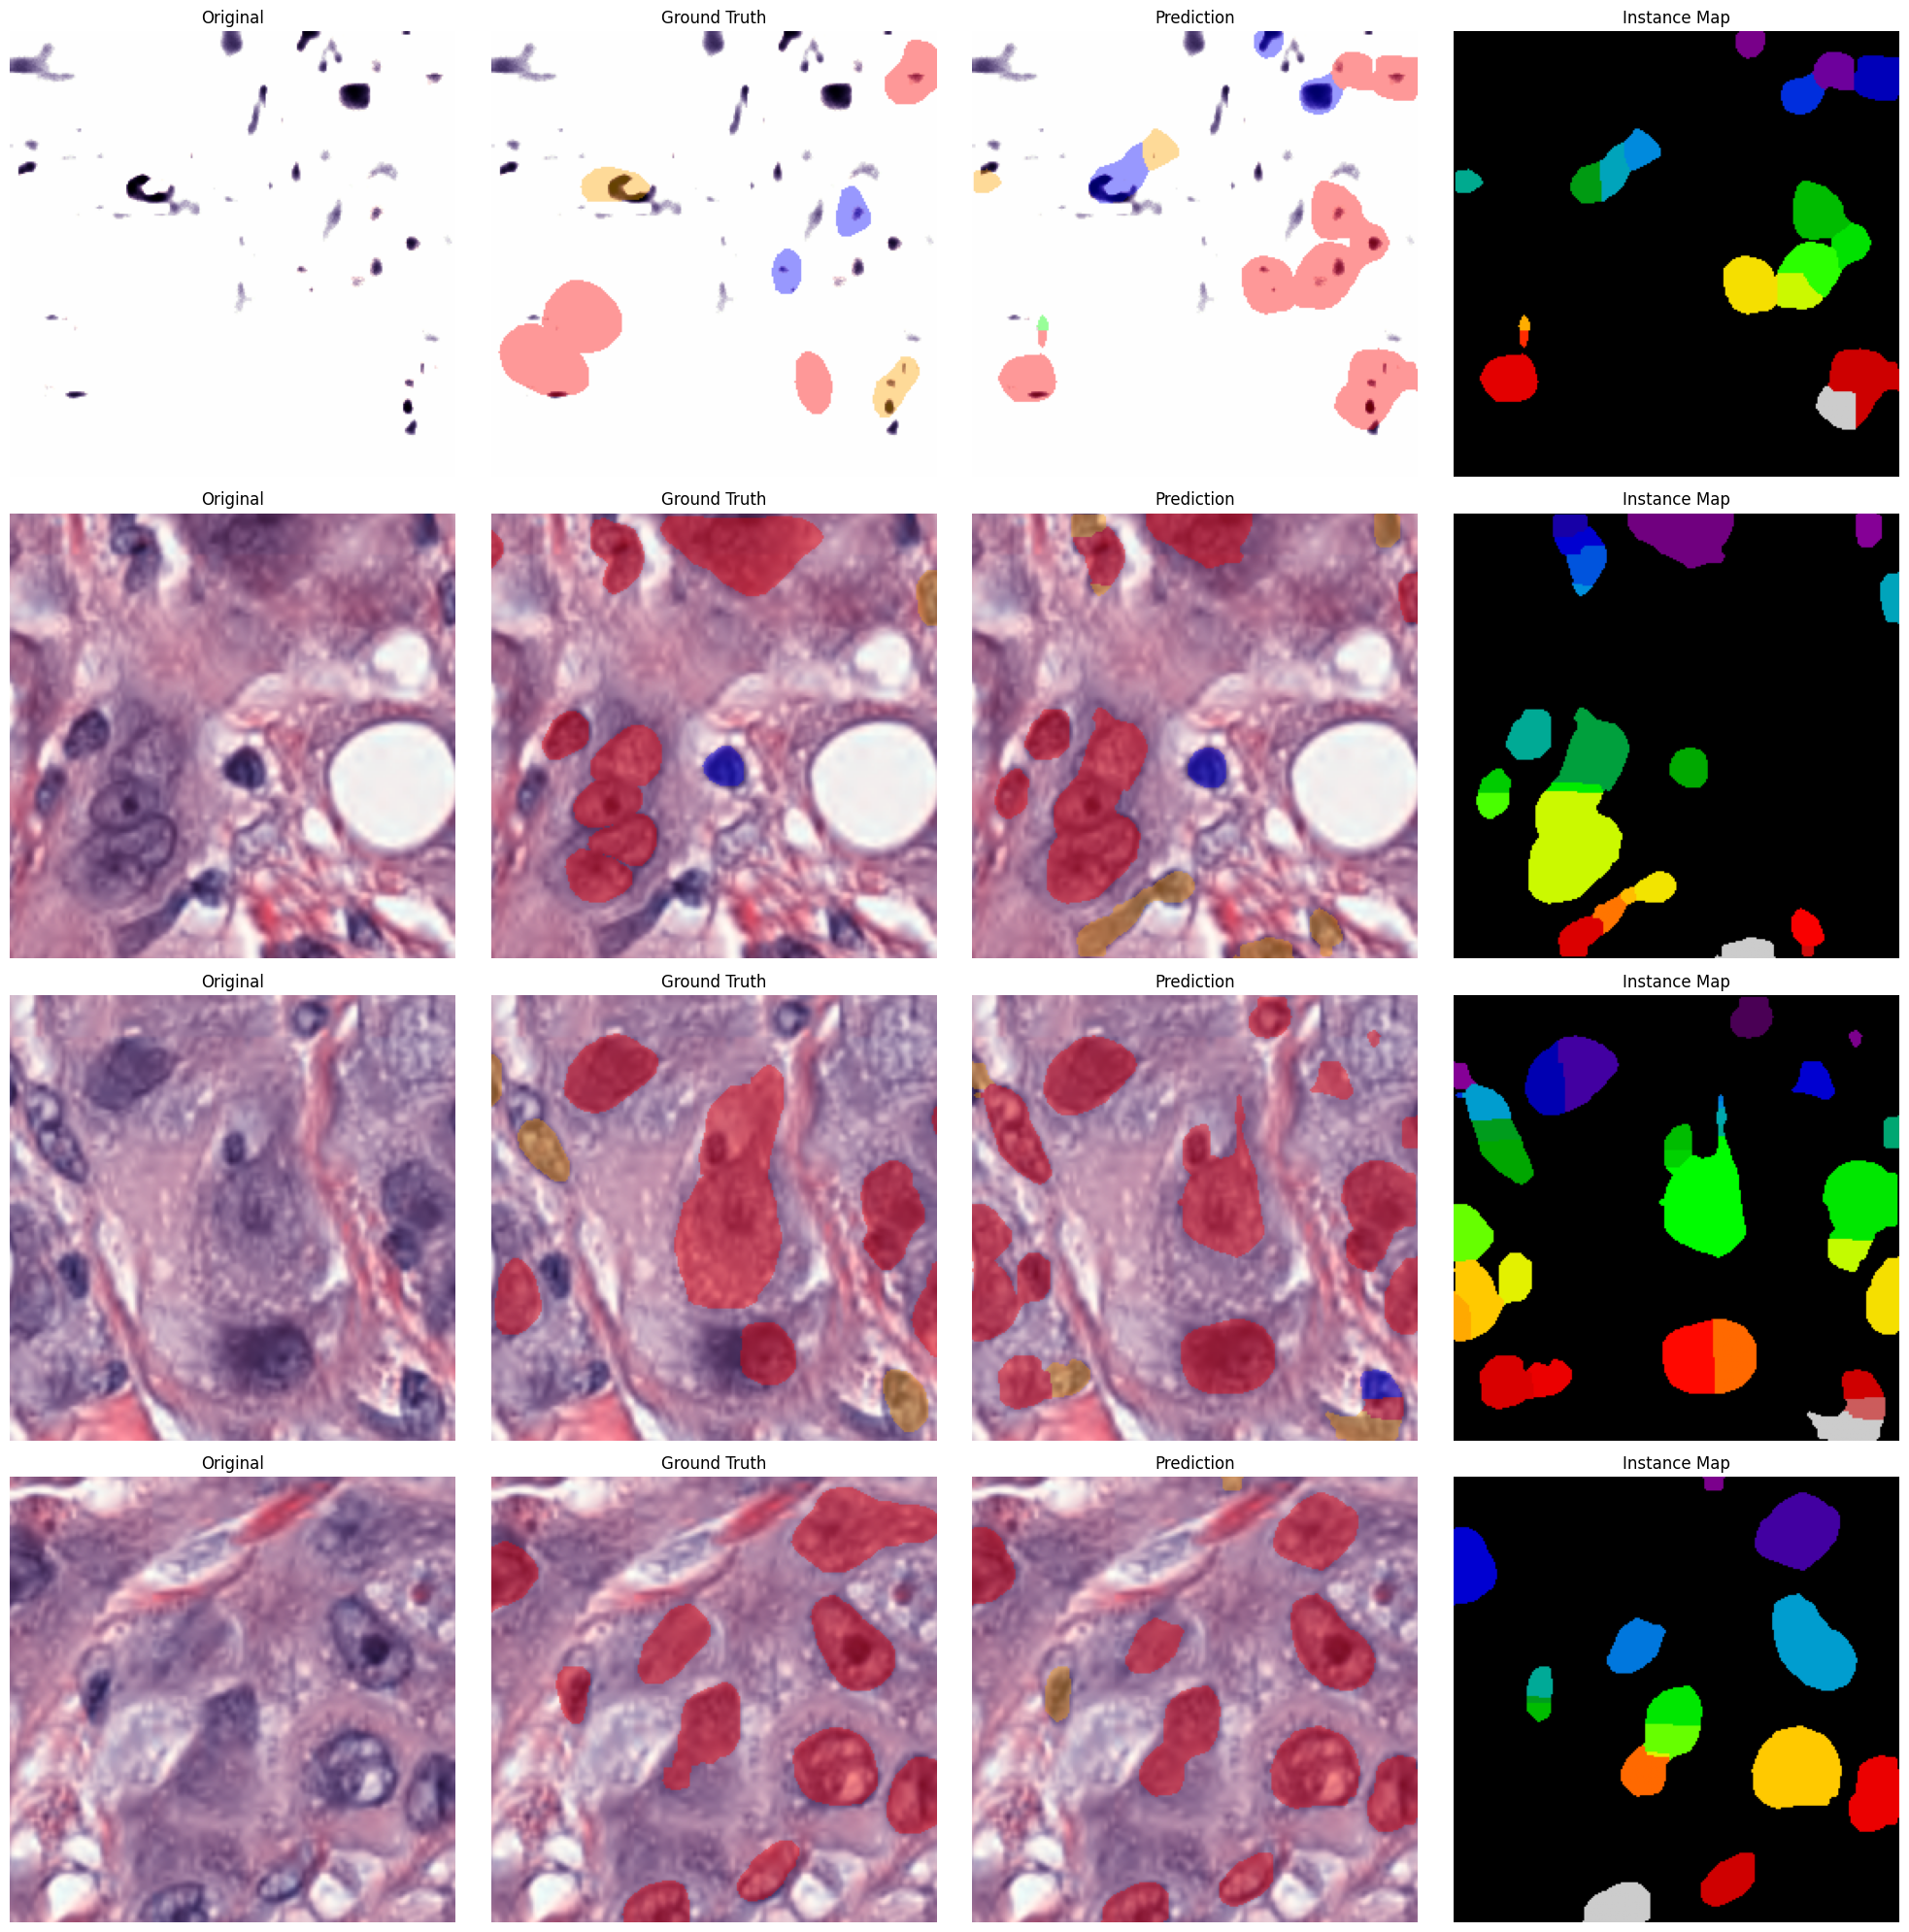

Improved training complete. Outputs saved to /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/outputs


In [22]:
# ============================================================
# 9.3 Execute Training
# ============================================================
import gc

all_results, all_histories, split_summaries = train_cellvit(fold_data, cfg)

with open(cfg.RESULTS_JSON, "w") as f:
    json.dump(
        [
            {k: float(v) if isinstance(v, (np.floating, float)) else v for k, v in r.items()}
            for r in all_results
        ],
        f,
        indent=2,
    )

print("\nSaving sample predictions from the final held-out fold...")
_, _, vis_loader, _, _ = create_fold_dataloaders(
    fold_data,
    test_fold=cfg.NUM_FOLDS,
    batch_size=cfg.BATCH_SIZE,
    num_workers=cfg.NUM_WORKERS,
)

model = CellViT(
    encoder_name=cfg.ENCODER_NAME,
    pretrained=cfg.ENCODER_PRETRAINED,
    num_classes=cfg.NUM_CLASSES,
    decoder_channels=cfg.DECODER_CHANNELS,
    img_size=cfg.PATCH_SIZE,
).to(device)

ckpt = torch.load(
    cfg.CHECKPOINT_DIR / f"assignment2_improved_best_model_fold{cfg.NUM_FOLDS}.pth",
    map_location=device,
)
model.load_state_dict(ckpt["model_state_dict"])

visualize_predictions(
    model,
    vis_loader,
    device,
    n_samples=4,
    save_path=cfg.SAMPLE_PREDICTIONS_PNG,
)

torch.cuda.empty_cache()
gc.collect()
print("Improved training complete. Outputs saved to", cfg.OUTPUT_DIR)

---
## 10. Results & Comparison <a id='10-results'></a>

This section summarizes both tracks:
- **Original constrained reproduction:** the honest low-budget baseline from Assignment 2
- **Improved reproduction:** better hardware plus full fine-tuning, cached preprocessing, class-aware loss weighting, and richer validation tracking


### Improved Reproduction Notes

This notebook copy is intentionally separated from the original Assignment 2 notebook so the original constrained reproduction stays unchanged. The improved copy keeps the same dataset protocol and metric family while adding:
- full fine-tuning instead of a frozen encoder
- longer training with early stopping
- cached preprocessing
- class-aware classification loss
- fold-wise reporting and richer qualitative analysis


In [79]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_final_comparison(output_dir="../outputs"):
    out_dir = Path(output_dir)
    
    # 1. Load Baseline Results
    baseline_file = out_dir / "results.json"
    baseline_mPQ = []
    baseline_F1 = []
    if baseline_file.exists():
        with open(baseline_file, "r") as f:
            base_data = json.load(f)
            # sort by fold just in case
            base_data = sorted(base_data, key=lambda x: x["fold"])
            baseline_mPQ = [d["mPQ"] for d in base_data]
            baseline_F1 = [d["F1_detection"] for d in base_data]
    else:
        print(f"Baseline results not found at: {baseline_file.absolute()}")
        return

    # 2. Load Improved Results
    improved_mPQ = []
    improved_F1 = []
    for i in range(1, 4):
        imp_file = out_dir / f"assignment2_improved_fold{i}_results.json"
        if imp_file.exists():
            with open(imp_file, "r") as f:
                imp_data = json.load(f)
                improved_mPQ.append(imp_data["mPQ"])
                improved_F1.append(imp_data["F1_detection"])
        else:
            print(f"Improved results for fold {i} not found at: {imp_file.absolute()}")
            return

    # 3. Plotting
    folds = ['Fold 1', 'Fold 2', 'Fold 3']
    x = np.arange(len(folds))
    width = 0.35

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # mPQ Plot
    rects1 = ax1.bar(x - width/2, baseline_mPQ, width, label='Baseline', color='#1f77b4', alpha=0.8)
    rects2 = ax1.bar(x + width/2, improved_mPQ, width, label='Improved', color='#ff7f0e', alpha=0.9)
    ax1.set_ylabel('mPQ Score')
    ax1.set_title('Multi-class Panoptic Quality (mPQ) Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(folds)
    ax1.legend()
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # F1 Detection Plot
    rects3 = ax2.bar(x - width/2, baseline_F1, width, label='Baseline', color='#1f77b4', alpha=0.8)
    rects4 = ax2.bar(x + width/2, improved_F1, width, label='Improved', color='#ff7f0e', alpha=0.9)
    ax2.set_ylabel('F1 Detection Score')
    ax2.set_title('Detection (F1) Score Comparison')
    ax2.set_xticks(x)
    ax2.set_xticklabels(folds)
    ax2.legend()
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels
    for ax, rects in [(ax1, rects1), (ax1, rects2), (ax2, rects3), (ax2, rects4)]:
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    save_path = out_dir / "assignment2_improved_final_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nSuccessfully generated and saved comparison plot to: {save_path.absolute()}")


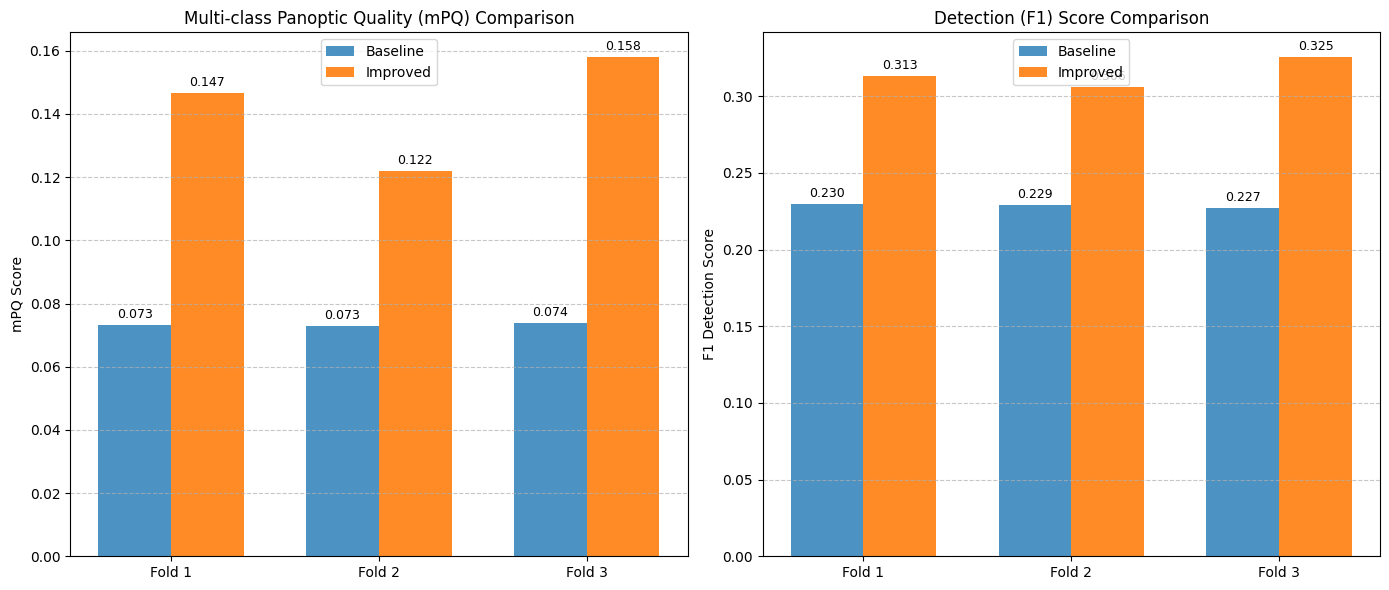


Successfully generated and saved comparison plot to: /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/notebook/../outputs/assignment2_improved_final_comparison.png


In [80]:
# Generate report-ready plots 
# Run the function
plot_final_comparison()

In [81]:
import json
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

# ============================================================
# 10.2 Results Comparison Table (Fixed)
# ============================================================
def print_results_comparison(output_dir="../outputs"):
    out_dir = Path(output_dir)
    
    # 1. Load Improved Results from disk since memory variables are empty
    all_results = []
    for i in range(1, 4):
        imp_file = out_dir / f"assignment2_improved_fold{i}_results.json"
        if imp_file.exists():
            with open(imp_file, "r") as f:
                all_results.append(json.load(f))
    
    if not all_results:
        print("No improved results found on disk.")
        return None, None, None

    # 2. Load Baseline Results from disk for fair comparison
    baseline_file = out_dir / "results.json"
    baseline_avg = {"mPQ": 0.0, "F1_detection": 0.0}
    if baseline_file.exists():
        with open(baseline_file, "r") as f:
            base_data = json.load(f)
            baseline_avg["mPQ"] = np.mean([d["mPQ"] for d in base_data])
            baseline_avg["F1_detection"] = np.mean([d["F1_detection"] for d in base_data])

    # 3. Calculate averages for Improved Results
    avg_results = defaultdict(list)
    for res in all_results:
        for key, val in res.items():
            if isinstance(val, (int, float, np.floating)):
                avg_results[key].append(val)

    avg = {k: np.mean(v) for k, v in avg_results.items()}
    std = {k: np.std(v) for k, v in avg_results.items()}

    print("\n" + "=" * 80)
    print("RESULTS COMPARISON: Original Constrained vs Improved Reproduction")
    print("=" * 80)
    print(f"{'Metric':<25} {'Baseline':>12} {'Improved':>18} {'Delta':>12}")
    print("-" * 80)

    for metric in ["mPQ", "F1_detection"]:
        baseline_val = baseline_avg.get(metric, 0.0)
        improved_val = avg.get(metric, 0.0)
        improved_std = std.get(metric, 0.0)
        delta = improved_val - baseline_val
        print(f"{metric:<25} {baseline_val:>12.4f} {improved_val:>10.4f} +/- {improved_std:<6.4f} {delta:>+12.4f}")

    print("-" * 80)
    print("\nPer-class PQ (mean +/- std):")
    
    # Dynamically extract classes from keys instead of relying on cfg variables
    classes = [k.replace("PQ_", "") for k in avg.keys() if k.startswith("PQ_")]
    for cls_name in classes:
        key = f"PQ_{cls_name}"
        print(f"  {cls_name:<18} {avg[key]:.4f} +/- {std[key]:.4f}")

    print("\nPer-fold summary:")
    for res in all_results:
        print(
            f"  Fold {res['fold']}: "
            f"mPQ={res['mPQ']:.4f}, "
            f"F1={res['F1_detection']:.4f}, "
            f"best_epoch={res.get('best_epoch', 'N/A')}"
        )

    print("=" * 80)

    # 4. Save to CSV
    df = pd.DataFrame(all_results)
    csv_path = out_dir / "assignment2_improved_fold_results.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nFold-wise results saved to {csv_path.absolute()}")

    # 5. Weak Classes Analysis
    weak_classes = []
    for cls_name in ["Inflammatory", "Dead"]:
        key = f"PQ_{cls_name}"
        if key in avg:
            weak_classes.append((cls_name, avg[key]))

    print("\nShort failure analysis:")
    if weak_classes:
        weak_classes = sorted(weak_classes, key=lambda x: x[1])
        for cls_name, score in weak_classes:
            print(f"  {cls_name} remains challenging (PQ={score:.4f}); likely affected by rarity, overlap ambiguity, and class confusion.")
    else:
        print("  Rare-class failure analysis is unavailable because the relevant class metrics were not produced.")

    return avg, std, df

# Run the fixed function
avg_results, std_results, fold_results_df = print_results_comparison()
display(fold_results_df)



RESULTS COMPARISON: Original Constrained vs Improved Reproduction
Metric                        Baseline           Improved        Delta
--------------------------------------------------------------------------------
mPQ                             0.0732     0.1422 +/- 0.0150      +0.0690
F1_detection                    0.2286     0.3149 +/- 0.0081      +0.0863
--------------------------------------------------------------------------------

Per-class PQ (mean +/- std):
  Neoplastic         0.1859 +/- 0.0160
  Inflammatory       0.1756 +/- 0.0108
  Connective         0.1175 +/- 0.0126
  Dead               0.0612 +/- 0.0210
  Epithelial         0.1708 +/- 0.0158

Per-fold summary:
  Fold 1: mPQ=0.1467, F1=0.3134, best_epoch=29
  Fold 2: mPQ=0.1220, F1=0.3059, best_epoch=30
  Fold 3: mPQ=0.1579, F1=0.3255, best_epoch=30

Fold-wise results saved to /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/notebook/../outputs/assignment2_improved_fold_results.csv

Short failure 

,PQ_Neoplastic,PQ_Inflammatory,PQ_Connective,PQ_Dead,PQ_Epithelial,mPQ,F1_detection,fold,best_epoch,best_val_loss
0,0.192713,0.174614,0.125337,0.069449,0.171306,0.146684,0.313431,1,29,2.306476
1,0.163818,0.162862,0.099831,0.032423,0.151221,0.122031,0.305899,2,30,2.010119
2,0.201226,0.189183,0.127449,0.081837,0.189956,0.157930,0.325472,3,30,2.240943


---
## 11. Reproducibility Discussion <a id='11-reproducibility-discussion'></a>

### 11.1 Expected Discrepancies

| Factor | Original Paper | Improved Notebook Copy | Impact |
|--------|---------------|------------------------|--------|
| GPU | NVIDIA A100 80GB | RTX 3080-class setup | Smaller batch size and shorter wall-clock budget |
| Backbone weights | SAM-scale setup in paper | timm ViT-Base pretrained | Different initialization quality |
| Batch size | Large-scale training budget | Practical local GPU budget | Affects gradient stability |
| Training duration | Long paper-scale training | 40 epochs with early stopping | Better than constrained A2, still below paper budget |
| Random seeds | Not specified | Fixed at 42 | Improves repeatability |

### 11.2 Key Implementation Improvements

1. **End-to-end fine-tuning:** the encoder is unfrozen from epoch 0.
2. **Longer training budget:** the copied notebook trains for up to 40 epochs with early stopping and best-checkpoint selection.
3. **Class imbalance handling:** class-weighted cross-entropy is applied to the nuclei classification branch.
4. **Cached preprocessing:** stain normalization and HoVer target generation are cached and reused across epochs.
5. **Stronger validation tracking:** validation loss, mPQ, F1-detection, and best epoch are tracked for every fold.

### 11.3 Why Results May Still Differ from the Paper

- The implementation still uses a simplified local reproduction path rather than the exact paper training stack.
- Post-processing sensitivity and watershed hyperparameters still influence final PQ.
- Rare classes such as Inflammatory and Dead remain harder due to low support and class confusion.

### 11.4 Conclusion

This improved notebook copy preserves the Assignment 2 structure while turning the earlier constrained run into a stronger and cleaner baseline. It is designed to produce more credible mPQ/F1 results and create fold-wise artifacts that can be reused directly in Assignment 3.


In [84]:
import json
import pandas as pd
import numpy as np
import torch
from pathlib import Path

# ============================================================
# 11.5 Export Experiment Logs (Fixed)
# ============================================================
def export_experiment_log(cfg):
    # Load all_results from disk
    all_results_loaded = []
    out_dir = Path(cfg.OUTPUT_DIR) if hasattr(cfg, 'OUTPUT_DIR') else Path("../outputs")
    
    for i in range(1, 4):
        imp_file = out_dir / f"assignment2_improved_fold{i}_results.json"
        if imp_file.exists():
            with open(imp_file, "r") as f:
                all_results_loaded.append(json.load(f))
                
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    log = {
        "experiment": "CellViT Improved Reproduction on PanNuke",
        "date": pd.Timestamp.now().isoformat(),
        "configuration": {
            "run_name": getattr(cfg, "RUN_NAME", "assignment2_improved"),
            "encoder": getattr(cfg, "ENCODER_NAME", "vit_base_patch16_224"),
            "batch_size": getattr(cfg, "BATCH_SIZE", 8),
            "learning_rate": getattr(cfg, "LEARNING_RATE", 0.0002),
            "weight_decay": getattr(cfg, "WEIGHT_DECAY", 0.01),
            "epochs": getattr(cfg, "NUM_EPOCHS", 30),
            "warmup_epochs": getattr(cfg, "WARMUP_EPOCHS", 5),
            "patience": getattr(cfg, "PATIENCE", 8),
            "optimizer": "AdamW",
            "scheduler": "Warmup + Cosine Decay",
            "freeze_encoder": getattr(cfg, "FREEZE_ENCODER", False),
            "mixed_precision": getattr(cfg, "USE_AMP", True),
            "cache_preprocess": getattr(cfg, "CACHE_PREPROCESS", True),
            "class_weighted_ce": getattr(cfg, "CLASS_WEIGHTED_CE", True),
            "seed": getattr(cfg, "SEED", 42),
            "patch_size": getattr(cfg, "PATCH_SIZE", 256),
        },
        "hardware": {
            "device": str(device),
            "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
            "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1) if torch.cuda.is_available() else 0,
            "pytorch_version": torch.__version__,
            "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
        },
        "dataset": {
            "name": "PanNuke",
            "num_folds": getattr(cfg, "NUM_FOLDS", 3),
            "num_classes": getattr(cfg, "NUM_CELL_TYPES", 5),
            "class_names": getattr(cfg, "CELL_CLASSES", ["Neoplastic", "Inflammatory", "Connective", "Dead", "Epithelial"]),
        },
        "baseline_reference": getattr(cfg, "BASELINE_RESULTS", {}),
    }

    if all_results_loaded:
        log["results"] = []
        for res in all_results_loaded:
            fold_log = {k: float(v) if isinstance(v, (np.floating, float)) else v for k, v in res.items()}
            log["results"].append(fold_log)

    log_path = getattr(cfg, "EXPERIMENT_LOG_JSON", out_dir / "assignment2_improved_experiment_log.json")
    
    with open(log_path, "w") as f:
        json.dump(log, f, indent=2, default=str)

    print(f"Experiment log saved to {log_path}")
    return log

# Run without passing the undefined variables!
experiment_log = export_experiment_log(cfg)

print("\nExperiment configuration:")
for section, content in experiment_log.items():
    if isinstance(content, dict):
        print(f"  {section}:")
        for k, v in content.items():
            print(f"    {k}: {v}")


Experiment log saved to /home/apath/Work/Shahoud/CNN-Transformer-Nuclei-Segmentation-main/outputs/assignment2_improved_experiment_log.json

Experiment configuration:
  configuration:
    run_name: assignment2_improved
    encoder: vit_base_patch16_224
    batch_size: 8
    learning_rate: 0.0002
    weight_decay: 0.01
    epochs: 30
    warmup_epochs: 5
    patience: 8
    optimizer: AdamW
    scheduler: Warmup + Cosine Decay
    freeze_encoder: False
    mixed_precision: True
    cache_preprocess: True
    class_weighted_ce: True
    seed: 42
    patch_size: 256
  hardware:
    device: cuda
    gpu_name: NVIDIA GeForce RTX 3080
    gpu_memory_gb: 10.0
    pytorch_version: 2.5.1+cu121
    cuda_version: 12.1
  dataset:
    name: PanNuke
    num_folds: 3
    num_classes: 5
    class_names: ['Neoplastic', 'Inflammatory', 'Connective', 'Dead', 'Epithelial']
  baseline_reference:
    mPQ: 0.0732
    F1_detection: 0.2286


In [85]:
# ============================================================
# QUICK START SUMMARY (Updated)
# ============================================================
print('''
+==================================================================+
|      CellViT Improved Reproduction -- Quick Start Guide          |
+==================================================================+
|                                                                  |
|  Step 1: Keep the original notebook unchanged                    |
|    -> Use this improved copy for the stronger A2 baseline        |
|                                                                  |
|  Step 2: Ensure PanNuke folds are available under PROJECT_ROOT / |
|         "data" / "pannuke"                                       |
|                                                                  |
|  Step 3: Run all cells above through Section 9.1                 |
|    -> This defines improved config, cache, model, loss, metrics  |
|                                                                  |
|  Step 4: Run Section 9.2                                         |
|    -> train_cellvit() will save the best models and results      |
|                                                                  |
|  Step 5: Review Section 10 outputs                               |
|    -> fold-wise table, mean/std summary, class-wise PQ plot      |
|    -> sample qualitative predictions                             |
|    -> baseline vs improved final comparison bar chart            |
|                                                                  |
|  Step 6: Export logs for Assignment 3 reuse                      |
|                                                                  |
|  Deliverables                                                    |
|    -> outputs/assignment2_improved_fold{1,2,3}_results.json      |
|    -> outputs/assignment2_improved_fold_results.csv              |
|    -> outputs/assignment2_improved_experiment_log.json           |
|    -> outputs/assignment2_improved_final_comparison.png          |
|    -> outputs/assignment2_improved_class_pq.png                  |
|    -> outputs/assignment2_improved_sample_predictions.png        |
|    -> checkpoints/assignment2_improved_best_model_fold{1,2,3}.pth|
|                                                                  |
+==================================================================+
''')



+==================================================================+
|      CellViT Improved Reproduction -- Quick Start Guide          |
+==================================================================+
|                                                                  |
|  Step 1: Keep the original notebook unchanged                    |
|    -> Use this improved copy for the stronger A2 baseline        |
|                                                                  |
|  Step 2: Ensure PanNuke folds are available under PROJECT_ROOT / |
|         "data" / "pannuke"                                       |
|                                                                  |
|  Step 3: Run all cells above through Section 9.1                 |
|    -> This defines improved config, cache, model, loss, metrics  |
|                                                                  |
|  Step 4: Run Section 9.2                                         |
|    -> train_cellvit() will save